# 🛒 Sales Analytics using Data Warehousing & Data Mining

**Course:** Data Warehousing & Mining (DWM) · **Type:** End-to-end mini project
**Dataset:** Superstore Sales — [Kaggle · rohitsahoo/sales-forecasting](https://www.kaggle.com/datasets/rohitsahoo/sales-forecasting)
**Team:** _<add names / roll numbers here>_

> **How to run:** upload this file to Google Colab → **Runtime ▸ Run all**. The data downloads itself, the web-scraping step fetches live data, and every model trains automatically (about 3–5 minutes). Nothing to upload or configure.

---

## 📑 Contents
| # | Section | DWM topic |
|---|---|---|
| 1 | Data collection | Dataset + data dictionary |
| 2 | Web scraping | Collecting external data |
| 3 | Data pre-processing | Cleaning, imputation, outliers, encoding, scaling |
| 4 | Star schema & OLAP | **Data warehousing** — fact/dimension tables, roll-up, drill-down, slice, dice |
| 5 | Exploratory data analysis | Visual analysis |
| 6 | Classification | Decision tree, Random Forest, Logistic Regression, KNN, Naive Bayes, XGBoost |
| 7 | Regression | Linear / Ridge / Tree / Forest / XGBoost + time-series forecast |
| 8 | Clustering | K-Means, Hierarchical, RFM customer segmentation |
| 9 | Association rules | **Apriori** (library + from scratch) |
| 10 | Bonus | Anomaly detection + live web app |
| 11 | Conclusions | Results, insights, limitations |

## 🎯 Problem statement
A retail business records every sale but cannot easily see *what happened, why, what will happen, and what to do about it*.
We build a small **data warehouse (star schema)** from the raw sales records and apply the standard **data-mining techniques**
(classification, regression, clustering, association rules) to turn that data into business decisions.

## 🧭 Pipeline
`Raw CSV` → **scrape** extra data → **pre-process** → load into **star schema (SQL)** → **EDA** → **mine** (classify · regress · cluster · associate) → **insights**

## ⚙️ 0. Setup
We use the standard Python data stack. `mlxtend` provides the Apriori algorithm (not pre-installed on Colab).

In [1]:
%pip install -q mlxtend

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings, io, re, sqlite3, time
from itertools import combinations
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import requests

PALETTE = ["#E8497B", "#8E7DBE", "#F7C948", "#5AA7A7", "#C64B8C", "#E9A178", "#2B2B33"]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = 40
RANDOM_STATE = 42
money = mtick.FuncFormatter(lambda x, _: f"${x:,.0f}")
print("Setup complete ✅")

Setup complete ✅


## 📥 1. Data collection

The dataset is the **Superstore Sales** data: one row per *product line on an order* for a US retailer, 2015–2018.
We download the CSV directly from a public mirror of the Kaggle dataset. If the download is blocked, Colab will ask you to upload `train.csv` (from the Kaggle page) instead.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/khairalanam/sales-forecast-excel-project/main/train.csv"
LOCAL_PATH = None            # e.g. "train.csv" if you already have the file next to the notebook

def load_data():
    if LOCAL_PATH:
        return pd.read_csv(LOCAL_PATH)
    try:
        return pd.read_csv(DATA_URL)
    except Exception as exc:
        print(f"Could not download the dataset ({type(exc).__name__}). Falling back to a manual upload...")
    from google.colab import files            # only available on Colab
    uploaded = files.upload()
    return pd.read_csv(io.BytesIO(next(iter(uploaded.values()))))

raw = load_data()
print(f"Loaded {raw.shape[0]:,} rows × {raw.shape[1]} columns")
raw.head()

Loaded 9,800 rows × 18 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,"42,420.00",South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,"90,036.00",West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,"33,311.00",South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37


In [4]:
data_dictionary = pd.DataFrame([
    ("Row ID",        "int",    "Row counter — carries no business meaning"),
    ("Order ID",      "text",   "Order identifier; one order has several rows (one per product)"),
    ("Order Date",    "date",   "When the order was placed (dd/mm/yyyy)"),
    ("Ship Date",     "date",   "When the order was shipped"),
    ("Ship Mode",     "text",   "Shipping class: Same Day / First / Second / Standard"),
    ("Customer ID",   "text",   "Customer identifier"),
    ("Customer Name", "text",   "Customer name"),
    ("Segment",       "text",   "Consumer / Corporate / Home Office"),
    ("Country",       "text",   "Always United States"),
    ("City",          "text",   "Delivery city"),
    ("State",         "text",   "Delivery state"),
    ("Postal Code",   "number", "Delivery ZIP code"),
    ("Region",        "text",   "Central / East / South / West"),
    ("Product ID",    "text",   "Product identifier"),
    ("Category",      "text",   "Furniture / Office Supplies / Technology"),
    ("Sub-Category",  "text",   "17 product types (Chairs, Phones, Binders, …)"),
    ("Product Name",  "text",   "Product description"),
    ("Sales",         "money",  "★ The only numeric measure: sales value of the line (USD)"),
], columns=["column", "type", "meaning"])
data_dictionary

,column,type,meaning
0,Row ID,int,Row counter — carries no business meaning
1,Order ID,text,Order identifier; one order has several rows (...
2,Order Date,date,When the order was placed (dd/mm/yyyy)
3,Ship Date,date,When the order was shipped
4,Ship Mode,text,Shipping class: Same Day / First / Second / St...
5,Customer ID,text,Customer identifier
6,Customer Name,text,Customer name
7,Segment,text,Consumer / Corporate / Home Office
8,Country,text,Always United States
9,City,text,Delivery city


In [5]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
raw[["Sales"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,"9,800.00",230.77,626.65,0.44,17.25,54.49,210.61,"22,638.48"


**Reading the summary:** there is *only one* numeric measure (`Sales`) — no quantity, discount or profit. That shapes every model below:
we can analyse **revenue**, not margin. Also note the huge gap between the median and the maximum sale: the distribution is extremely skewed (we deal with that in pre-processing).

## 🌐 2. Web scraping — enriching the data with US state populations

Sales totals alone favour big states. To judge a state fairly we need its **population**, which is not in the dataset — so we **scrape** it from Wikipedia
(*List of U.S. states and territories by population*, 2020 Census column) and use it later as a new attribute in the warehouse (`dim_geography`) and in the models.

**How the scraper works**
1. `requests.get` downloads the page (with a polite `User-Agent`; one request only).
2. `pandas.read_html` parses every HTML `<table>`; we pick the population table.
3. Clean-up: flatten the two-row header, strip footnote markers like `[a]`, remove commas, convert to integers.
4. Keep only the 50 states + D.C. (drop territories and total rows).

> Wikipedia text is CC BY-SA licensed; we fetch a single page for coursework purposes. If the live request ever fails (no internet, layout change), the notebook falls back to an embedded copy of a previous scrape so it never breaks.

In [7]:
WIKI_URL = "https://en.wikipedia.org/wiki/List_of_U.S._states_and_territories_by_population"
US_STATES = [
    "Alabama","Alaska","Arizona","Arkansas","California","Colorado","Connecticut","Delaware","Florida","Georgia",
    "Hawaii","Idaho","Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana","Maine","Maryland","Massachusetts",
    "Michigan","Minnesota","Mississippi","Missouri","Montana","Nebraska","Nevada","New Hampshire","New Jersey",
    "New Mexico","New York","North Carolina","North Dakota","Ohio","Oklahoma","Oregon","Pennsylvania","Rhode Island",
    "South Carolina","South Dakota","Tennessee","Texas","Utah","Vermont","Virginia","Washington","West Virginia",
    "Wisconsin","Wyoming","District of Columbia",
]

FALLBACK_CSV = """state,population_2020
California,39538223
Texas,29145505
Florida,21538187
New York,20201249
Pennsylvania,13002700
Illinois,12812508
Ohio,11799448
Georgia,10711908
North Carolina,10439388
Michigan,10077331
New Jersey,9288994
Virginia,8631393
Washington,7705281
Arizona,7151502
Tennessee,6910840
Massachusetts,7029917
Indiana,6785528
Missouri,6154913
Maryland,6177224
Colorado,5773714
Wisconsin,5893718
Minnesota,5706494
South Carolina,5118425
Alabama,5024279
Louisiana,4657757
Kentucky,4505836
Oregon,4237256
Oklahoma,3959353
Connecticut,3605944
Utah,3271616
Nevada,3104614
Iowa,3190369
Arkansas,3011524
Kansas,2937880
Mississippi,2961279
New Mexico,2117522
Idaho,1839106
Nebraska,1961504
West Virginia,1793716
Hawaii,1455271
New Hampshire,1377529
Maine,1362359
Montana,1084225
Rhode Island,1097379
Delaware,989948
South Dakota,886667
North Dakota,779094
Alaska,733391
District of Columbia,689545
Vermont,643077
Wyoming,576851"""

def scrape_state_population():
    resp = requests.get(WIKI_URL, headers={"User-Agent": "Mozilla/5.0 (DWM college project)"}, timeout=30)
    resp.raise_for_status()
    tables = pd.read_html(io.StringIO(resp.text))          # every <table> on the page
    t = tables[0]
    t.columns = [" | ".join(map(str, c)) if isinstance(c, tuple) else str(c) for c in t.columns]
    state_col = next(c for c in t.columns if c.startswith("State or territory"))
    pop_col   = next(c for c in t.columns if "April 1, 2020" in c)
    out = t[[state_col, pop_col]].copy()
    out.columns = ["state", "population_2020"]
    out["state"] = out["state"].astype(str).str.replace(r"\[.*?\]", "", regex=True).str.strip()
    out["population_2020"] = pd.to_numeric(
        out["population_2020"].astype(str).str.replace(r"[^\d]", "", regex=True), errors="coerce")
    return out[out["state"].isin(US_STATES)].dropna().reset_index(drop=True)

try:
    state_pop = scrape_state_population()
    assert len(state_pop) >= 50, "unexpected table layout"
    scrape_source = "live scrape of Wikipedia"
except Exception as exc:
    print(f"Live scrape failed ({type(exc).__name__}: {exc}) → using the embedded copy.")
    state_pop = pd.read_csv(io.StringIO(FALLBACK_CSV))
    scrape_source = "embedded copy of an earlier scrape"

state_pop["population_2020"] = state_pop["population_2020"].astype(int)
print(f"Source: {scrape_source} · {len(state_pop)} rows · total population {state_pop['population_2020'].sum():,}")
state_pop.head(8)

Source: live scrape of Wikipedia · 51 rows · total population 331,449,281


,state,population_2020
0,California,39538223
1,Texas,29145505
2,Florida,21538187
3,New York,20201249
4,Pennsylvania,13002700
5,Illinois,12812508
6,Ohio,11799448
7,Georgia,10711908


States in the sales data: 49 · matched by the scrape: 49 · unmatched: none


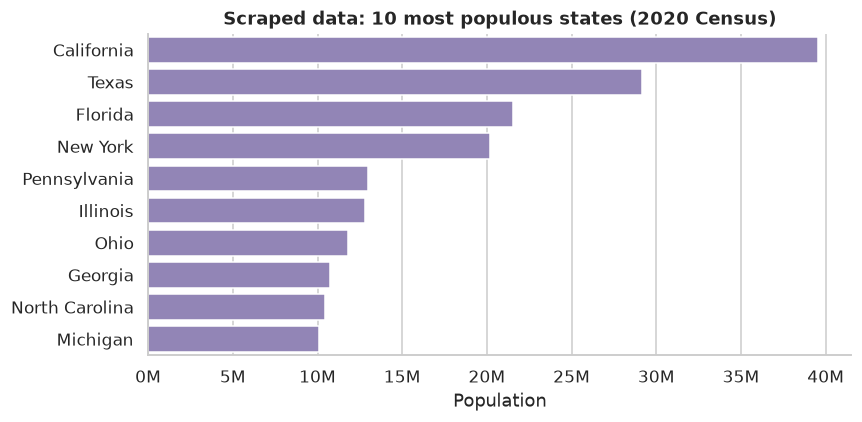

In [8]:
# Sanity checks on the scraped data + a quick visual
sales_states = set(raw["State"])
missing_in_scrape = sorted(sales_states - set(state_pop["state"]))
print(f"States in the sales data: {len(sales_states)} · matched by the scrape: {len(sales_states) - len(missing_in_scrape)} · unmatched: {missing_in_scrape or 'none'}")

top = state_pop.sort_values("population_2020", ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=top, y="state", x="population_2020", color=PALETTE[1], ax=ax)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.set(title="Scraped data: 10 most populous states (2020 Census)", xlabel="Population", ylabel="")
plt.tight_layout(); plt.show()

## 🧹 3. Data pre-processing

Raw data is never model-ready. We follow a fixed checklist and **show evidence at every step**:

| Step | Question |
|---|---|
| 3.1 Audit | What is wrong with the raw data? |
| 3.2 Data types | Are dates / ZIP codes stored correctly? |
| 3.3 Missing values | Which values are missing and how do we fill them? |
| 3.4 Duplicates | Are any records repeated? |
| 3.5 Consistency | Do the business rules hold? |
| 3.6 Feature engineering | What useful columns can we derive? |
| 3.7 Outliers & skew | Are extreme values errors or real? |
| 3.8 Encoding & scaling | How do we make data digestible for algorithms? |
| 3.9 Before vs after | Did we improve quality? |

### 3.1 Audit of the raw data

In [9]:
def quality_report(d):
    return pd.DataFrame({
        "dtype":  d.dtypes.astype(str),
        "nulls":  d.isna().sum(),
        "null_%": (d.isna().mean() * 100).round(2),
        "unique": d.nunique(),
    })

audit_before = quality_report(raw)
n_dupes_raw = int(raw.drop(columns="Row ID").duplicated().sum())
print(f"Total missing cells: {int(raw.isna().sum().sum())} · duplicate records (ignoring Row ID): {n_dupes_raw}")
audit_before

Total missing cells: 11 · duplicate records (ignoring Row ID): 1


,dtype,nulls,null_%,unique
Row ID,int64,0,0.00,9800
Order ID,str,0,0.00,4922
Order Date,str,0,0.00,1230
Ship Date,str,0,0.00,1326
Ship Mode,str,0,0.00,4
Customer ID,str,0,0.00,793
Customer Name,str,0,0.00,793
Segment,str,0,0.00,3
Country,str,0,0.00,1
City,str,0,0.00,529


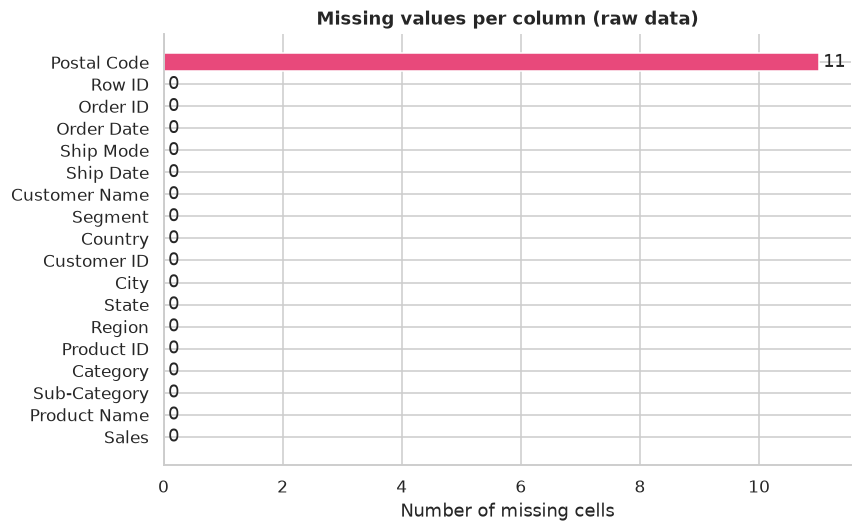

In [10]:
nulls = raw.isna().sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE[0] if v > 0 else "#D9D9E3" for v in nulls.values]
bars = ax.barh(nulls.index, nulls.values, color=colors)
ax.bar_label(bars, padding=3)
ax.invert_yaxis()
ax.set(title="Missing values per column (raw data)", xlabel="Number of missing cells")
plt.tight_layout(); plt.show()

**Finding:** the data is mostly complete — only `Postal Code` has gaps — but a "mostly complete" file still hides problems (wrong types, a duplicate, extreme skew). We go step by step.

### 3.2 Fixing data types
Dates arrive as text. Before parsing we must know the format: is `08/11/2017` the 8th of November or the 11th of August? We look for evidence — any date whose first number is greater than 12 *must* be a day.

In [11]:
df = raw.copy()

first_part = df["Order Date"].str.split("/").str[0].astype(int)
print(f"Order dates whose first number is > 12: {(first_part > 12).sum():,}  →  the first number is the DAY (format dd/mm/yyyy)")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  format="%d/%m/%Y")
print(f"Order dates now run from {df['Order Date'].min():%d %b %Y} to {df['Order Date'].max():%d %b %Y}")
df[["Order Date", "Ship Date"]].dtypes

Order dates whose first number is > 12: 5,841  →  the first number is the DAY (format dd/mm/yyyy)
Order dates now run from 03 Jan 2015 to 30 Dec 2018


Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

### 3.3 Missing values — `Postal Code`
First: *where* are the gaps?

In [12]:
missing_mask = df["Postal Code"].isna()
print(f"{missing_mask.sum()} rows have no postal code. Their city/state:")
df.loc[missing_mask, ["City", "State"]].value_counts().to_frame("rows")

11 rows have no postal code. Their city/state:


,,rows
City,State,
Burlington,Vermont,11


All the gaps belong to **one place — Burlington, Vermont**. That makes the choice easy:

| Option | Verdict |
|---|---|
| Drop the 11 rows | Loses real sales (information loss) |
| Fill with the most common ZIP | Wrong — would put Vermont sales in another state |
| Fill with the **known ZIP of Burlington, VT (05401)** — domain knowledge | ✅ Correct and transparent |

We also add a flag column `postal_imputed` so the change is traceable.

**Bonus catch:** ZIP codes were read as numbers, which silently drops leading zeros (Vermont's `05401` becomes `5401`). ZIP codes are *identifiers, not quantities*, so we store them as 5-character text.

In [13]:
df["postal_imputed"] = missing_mask
df.loc[missing_mask, "Postal Code"] = 5401                       # Burlington, VT
df["Postal Code"] = df["Postal Code"].astype(int).astype(str).str.zfill(5)

print("Missing postal codes after imputation:", int(df["Postal Code"].isna().sum()))
print("Example (leading zero restored):", df.loc[missing_mask, "Postal Code"].iloc[0])

Missing postal codes after imputation: 0
Example (leading zero restored): 05401


### 3.4 Duplicate records
A record that is identical in *every* business field (order, product, customer, place, sales) is almost certainly a double entry. `Row ID` is just a counter, so we ignore it when comparing.

In [14]:
biz_cols = [c for c in df.columns if c != "Row ID"]
dupe_any = df.duplicated(subset=biz_cols, keep=False)
display(df.loc[dupe_any, ["Row ID", "Order ID", "Product ID", "Customer ID", "Sales"]])

before = len(df)
df = df.drop_duplicates(subset=biz_cols, keep="first").reset_index(drop=True)
print(f"Rows: {before:,} → {len(df):,}  ({before - len(df)} duplicate removed)")

,Row ID,Order ID,Product ID,Customer ID,Sales
3405,3406,US-2015-150119,FUR-CH-10002965,LB-16795,281.37
3406,3407,US-2015-150119,FUR-CH-10002965,LB-16795,281.37


Rows: 9,800 → 9,799  (1 duplicate removed)


### 3.5 Consistency checks (business rules)
Before trusting the data we test rules that *must* be true. Each check below should read `True`; anything `False` needs a decision.

In [15]:
for c in ["Order ID", "Ship Mode", "Customer ID", "Customer Name", "Segment", "Country", "City", "State",
          "Region", "Product ID", "Category", "Sub-Category", "Product Name"]:
    df[c] = df[c].astype(str).str.strip()                         # remove stray whitespace

one_to_one = lambda a, b: bool((df.groupby(a)[b].nunique() == 1).all())
checks = pd.Series({
    "Each Customer ID has exactly one name":           one_to_one("Customer ID", "Customer Name"),
    "Each Customer ID has exactly one segment":        one_to_one("Customer ID", "Segment"),
    "Each State belongs to exactly one Region":        one_to_one("State", "Region"),
    "Each Sub-Category belongs to one Category":       one_to_one("Sub-Category", "Category"),
    "Each Product ID has exactly one Category":        one_to_one("Product ID", "Category"),
    "Each Product ID has exactly one Product Name":    one_to_one("Product ID", "Product Name"),
    "Ship Date is never before Order Date":            bool((df["Ship Date"] >= df["Order Date"]).all()),
    "Sales is always positive":                        bool((df["Sales"] > 0).all()),
}, name="passes?")
checks.to_frame()

,passes?
Each Customer ID has exactly one name,True
Each Customer ID has exactly one segment,True
Each State belongs to exactly one Region,True
Each Sub-Category belongs to one Category,True
Each Product ID has exactly one Category,True
Each Product ID has exactly one Product Name,False
Ship Date is never before Order Date,True
Sales is always positive,True


In [16]:
multi_name = df.groupby("Product ID")["Product Name"].nunique()
multi_name = multi_name[multi_name > 1]
print(f"{len(multi_name)} Product IDs appear under more than one product name. Example:")
ex = multi_name.index[0]
display(df.loc[df["Product ID"] == ex, ["Product ID", "Product Name"]].value_counts().to_frame("rows"))

32 Product IDs appear under more than one product name. Example:


rows
Product ID      Product Name                                          
FUR-BO-10002213 DMI Eclipse Executive Suite Bookcases                6
                Sauder Forest Hills Library, Woodland Oak Finish     4

**Decision:** a small share of product IDs carry more than one name (the same product renamed over time). The **ID is the reliable key**, so in the warehouse (section 4) each product ID gets *one* name — its most frequent one. Everything else passes.

### 3.6 Feature engineering
New columns derived from existing ones give the models and charts something to work with.

In [17]:
df["order_year"]       = df["Order Date"].dt.year
df["order_quarter"]    = df["Order Date"].dt.quarter
df["order_month"]      = df["Order Date"].dt.month
df["order_month_name"] = df["Order Date"].dt.month_name()
df["order_weekday"]    = df["Order Date"].dt.day_name()
df["ship_days"]        = (df["Ship Date"] - df["Order Date"]).dt.days       # delivery lead time
df["log_sales"]        = np.log1p(df["Sales"])                              # tames the skew (see 3.7)

print("Ship lead time (days):", df["ship_days"].min(), "to", df["ship_days"].max())
df[["Order Date", "order_year", "order_quarter", "order_month_name", "order_weekday", "ship_days", "Sales", "log_sales"]].head()

Ship lead time (days): 0 to 7


,Order Date,order_year,order_quarter,order_month_name,order_weekday,ship_days,Sales,log_sales
0,2017-11-08,2017,4,November,Wednesday,3,261.96,5.57
1,2017-11-08,2017,4,November,Wednesday,3,731.94,6.60
2,2017-06-12,2017,2,June,Monday,4,14.62,2.75
3,2016-10-11,2016,4,October,Tuesday,7,957.58,6.87
4,2016-10-11,2016,4,October,Tuesday,7,22.37,3.15


### 3.7 Outliers and skewness
`Sales` is the only measure, so its shape matters. We inspect it with a box-plot and the **IQR rule** (a value is an outlier if it lies above Q3 + 1.5 × IQR).

Q1 = $17.25 · Q3 = $210.57 · IQR = $193.32 · upper fence = $500.56
Outliers: 1,145 rows (11.7%) · skewness before = 12.98 · after log transform = 0.28


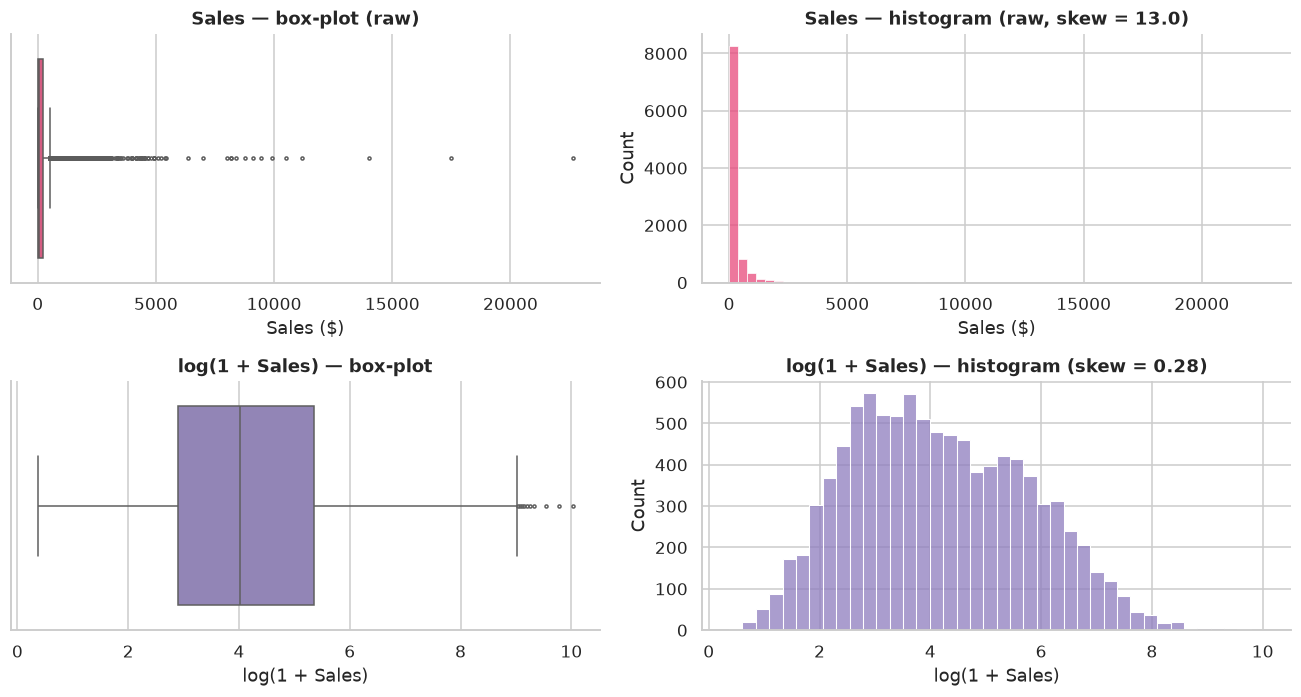

In [18]:
q1, q3 = df["Sales"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
df["is_outlier"] = df["Sales"] > upper_fence

print(f"Q1 = ${q1:,.2f} · Q3 = ${q3:,.2f} · IQR = ${iqr:,.2f} · upper fence = ${upper_fence:,.2f}")
print(f"Outliers: {df['is_outlier'].sum():,} rows ({df['is_outlier'].mean():.1%}) · skewness before = {df['Sales'].skew():.2f} · after log transform = {df['log_sales'].skew():.2f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5))
sns.boxplot(x=df["Sales"], ax=axes[0, 0], color=PALETTE[0], fliersize=2)
axes[0, 0].set(title="Sales — box-plot (raw)", xlabel="Sales ($)")
sns.histplot(df["Sales"], bins=60, ax=axes[0, 1], color=PALETTE[0])
axes[0, 1].set(title=f"Sales — histogram (raw, skew = {df['Sales'].skew():.1f})", xlabel="Sales ($)")
sns.boxplot(x=df["log_sales"], ax=axes[1, 0], color=PALETTE[1], fliersize=2)
axes[1, 0].set(title="log(1 + Sales) — box-plot", xlabel="log(1 + Sales)")
sns.histplot(df["log_sales"], bins=40, ax=axes[1, 1], color=PALETTE[1])
axes[1, 1].set(title=f"log(1 + Sales) — histogram (skew = {df['log_sales'].skew():.2f})", xlabel="log(1 + Sales)")
plt.tight_layout(); plt.show()

Largest 5 sales:


,Order ID,Sub-Category,Product Name,Sales
2697,CA-2015-145317,Machines,Cisco TelePresence System EX90 Videoconferenci...,"22,638.48"
6825,CA-2017-118689,Copiers,Canon imageCLASS 2200 Advanced Copier,"17,499.95"
8152,CA-2018-140151,Copiers,Canon imageCLASS 2200 Advanced Copier,"13,999.96"
2623,CA-2018-127180,Copiers,Canon imageCLASS 2200 Advanced Copier,"11,199.97"
4189,CA-2018-166709,Copiers,Canon imageCLASS 2200 Advanced Copier,"10,499.97"


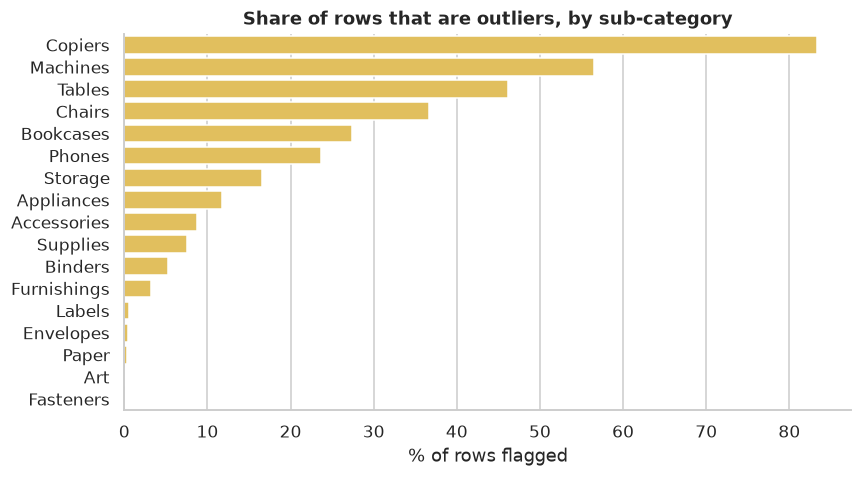

In [19]:
# Are the outliers errors, or genuine big-ticket sales?
print("Largest 5 sales:")
display(df.nlargest(5, "Sales")[["Order ID", "Sub-Category", "Product Name", "Sales"]])

by_sub = (df.groupby("Sub-Category")["is_outlier"].mean().sort_values(ascending=False) * 100).round(1)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=by_sub.values, y=by_sub.index, color=PALETTE[2], ax=ax)
ax.set(title="Share of rows that are outliers, by sub-category", xlabel="% of rows flagged", ylabel="")
plt.tight_layout(); plt.show()

**Decision — keep, don't delete.** The outliers are not typing errors: they are expensive products (copiers, machines, conference-room tech) and they concentrate in a few sub-categories. Deleting them would remove exactly the sales a business cares about most.
Instead we **flag** them (`is_outlier`) and **log-transform** the target for modelling, which reduces skewness from the value shown above to near zero.

### 3.8 Encoding and scaling
Algorithms work on numbers, so categories must be **encoded**; and features on different scales (a ZIP-like count vs a dollar amount) must be **scaled**.

In [20]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

demo = df[["Ship Mode", "Sales"]].head(6).copy()
demo["label_encoded"] = LabelEncoder().fit_transform(demo["Ship Mode"])
onehot = pd.get_dummies(demo["Ship Mode"], prefix="mode").astype(int)
print("Label encoding invents an order (0 < 1 < 2 …) that does not exist; one-hot encoding does not.")
pd.concat([demo, onehot], axis=1)

Label encoding invents an order (0 < 1 < 2 …) that does not exist; one-hot encoding does not.


,Ship Mode,Sales,label_encoded,mode_Second Class,mode_Standard Class
0,Second Class,261.96,0,1,0
1,Second Class,731.94,0,1,0
2,Second Class,14.62,0,1,0
3,Standard Class,957.58,1,0,1
4,Standard Class,22.37,1,0,1
5,Standard Class,48.86,1,0,1


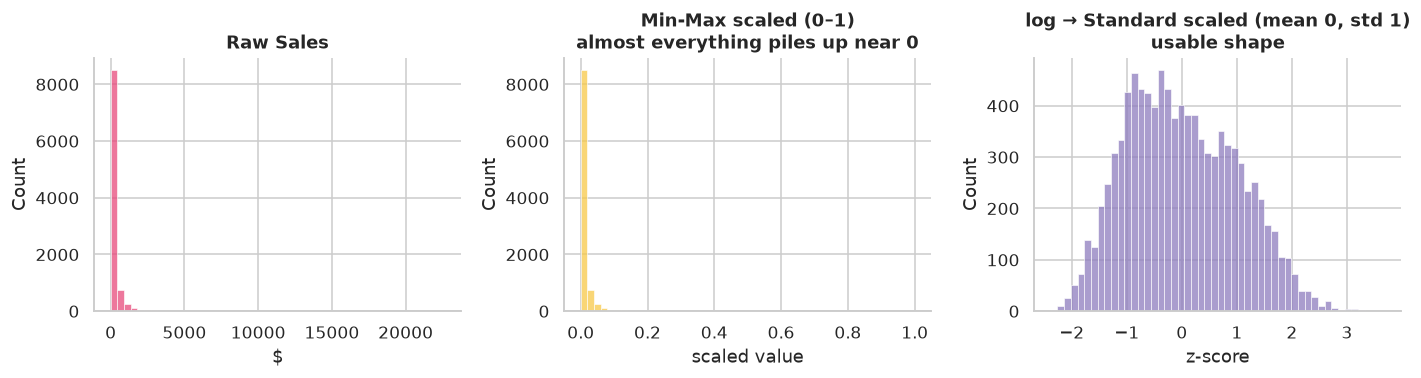

,mean,std,min,max
Raw Sales,230.76,626.68,0.44,"22,638.48"
Min-Max scaled,0.01,0.03,0.00,1.00
log + Standard scaled,-0.00,1.00,-2.38,3.69


In [21]:
sales = df[["Sales"]]
minmax_raw   = MinMaxScaler().fit_transform(sales)                       # squeezed by outliers
std_log      = StandardScaler().fit_transform(df[["log_sales"]])         # log first, then standardise

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
sns.histplot(sales["Sales"], bins=50, ax=axes[0], color=PALETTE[0]);  axes[0].set(title="Raw Sales", xlabel="$")
sns.histplot(minmax_raw.ravel(), bins=50, ax=axes[1], color=PALETTE[2]); axes[1].set(title="Min-Max scaled (0–1)\nalmost everything piles up near 0", xlabel="scaled value")
sns.histplot(std_log.ravel(), bins=50, ax=axes[2], color=PALETTE[1]);    axes[2].set(title="log → Standard scaled (mean 0, std 1)\nusable shape", xlabel="z-score")
plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    "mean": [sales["Sales"].mean(), minmax_raw.mean(), std_log.mean()],
    "std":  [sales["Sales"].std(),  minmax_raw.std(),  std_log.std()],
    "min":  [sales["Sales"].min(),  minmax_raw.min(),  std_log.min()],
    "max":  [sales["Sales"].max(),  minmax_raw.max(),  std_log.max()],
}, index=["Raw Sales", "Min-Max scaled", "log + Standard scaled"])
summary

**Takeaway:** with extreme outliers, Min-Max scaling squashes 90% of the data into a sliver. *Log first, then standardise* gives a well-behaved feature. In the modelling sections we use **one-hot encoding** for categories and **standard scaling** for numbers, wrapped in a scikit-learn `ColumnTransformer` so the exact same steps are applied to training and test data (no leakage).

### 3.9 Before vs after

In [22]:
clean = df.copy()

comparison = pd.DataFrame({
    "Raw data": [len(raw), raw.shape[1], int(raw.isna().sum().sum()), n_dupes_raw,
                 raw["Order Date"].dtype.name, raw["Postal Code"].dtype.name, 0],
    "Clean data": [len(clean), clean.shape[1], int(clean.isna().sum().sum()),
                   int(clean.duplicated(subset=biz_cols).sum()),
                   clean["Order Date"].dtype.name, clean["Postal Code"].dtype.name, int(clean["is_outlier"].sum())],
}, index=["Rows", "Columns", "Missing cells", "Duplicate rows", "Order Date type", "Postal Code type",
          "Outliers flagged (kept)"])
display(comparison.astype(str))
print(f"\nSales total is preserved apart from the one duplicate: raw ${raw['Sales'].sum():,.2f} → clean ${clean['Sales'].sum():,.2f}")

,Raw data,Clean data
Rows,9800,9799
Columns,18,27
Missing cells,11,0
Duplicate rows,1,0
Order Date type,str,datetime64[us]
Postal Code type,float64,str
Outliers flagged (kept),0,1145



Sales total is preserved apart from the one duplicate: raw $2,261,536.78 → clean $2,261,255.41


## 🏛️ 4. Data warehouse — star schema & OLAP

A flat CSV is fine for one-off analysis, but a business needs a **data warehouse**: a structure designed for *answering analytical questions fast and consistently*.
The classic design is the **star schema**:

* one central **fact table** holding the numbers we measure (here: `sales`), one row per event;
* several surrounding **dimension tables** describing *who / what / where / when* (customer, product, geography, date, shipping).

The fact table points to each dimension through a **foreign key**, so the picture looks like a star.

### Design decisions
| Decision | Our choice | Why |
|---|---|---|
| **Grain** (what one fact row means) | One *product line on an order* | Finest detail available → can always roll up, never drill below |
| **Measures** | `sales` (additive), `ship_days` | Numbers we aggregate |
| **Dimensions** | Date, Customer, Product, Geography, Ship Mode | Every question is "sales by ___" |
| **Degenerate dimension** | `order_id` stays in the fact table | It identifies the order but has no attributes of its own |
| **Role-playing dimension** | `dim_date` is used twice: `order_date_key` and `ship_date_key` | One calendar table, two meanings |
| **Surrogate keys** | Integer keys (`customer_key`, …) | Stable, small, independent of business IDs |
| **Enrichment** | `dim_geography.state_population_2020` (from our web scrape) | Lets us compute *revenue per resident* |

**Star vs snowflake:** a snowflake schema further normalises dimensions (e.g. a separate `category` table). It saves a little space but needs more joins; with small dimensions like ours, the star's simplicity and speed win.

### 4.1 The schema diagram

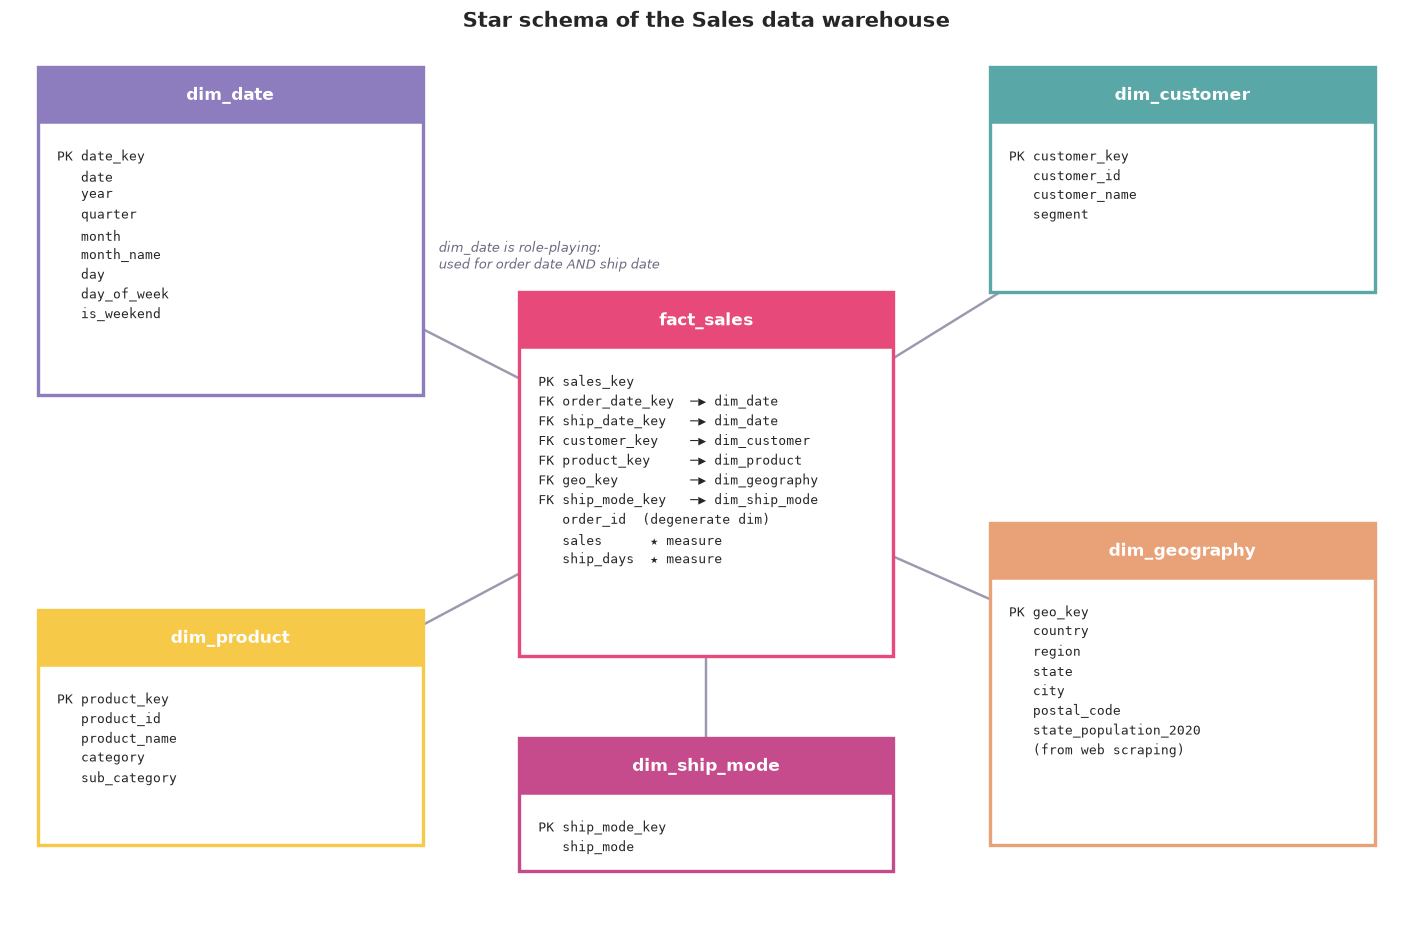

In [23]:
def draw_star_schema():
    fig, ax = plt.subplots(figsize=(13, 8.6))
    ax.set_xlim(0, 13); ax.set_ylim(0, 8.6); ax.axis("off")

    def box(x, y, w, h, title, lines, color):
        ax.add_patch(plt.Rectangle((x, y), w, h, fc="white", ec=color, lw=2.2, zorder=3))
        ax.add_patch(plt.Rectangle((x, y + h - 0.55), w, 0.55, fc=color, ec=color, zorder=4))
        ax.text(x + w / 2, y + h - 0.28, title, ha="center", va="center", color="white",
                weight="bold", fontsize=11, zorder=5)
        ax.text(x + 0.18, y + h - 0.78, "\n".join(lines), ha="left", va="top", fontsize=8.6,
                family="monospace", linespacing=1.5, zorder=5)

    fact = (4.75, 2.55, 3.5, 3.55)
    dims = {
        "dim_date":      (0.25, 5.1, 3.6, 3.2, PALETTE[1],
                          ["PK date_key", "   date", "   year", "   quarter", "   month", "   month_name", "   day",
                           "   day_of_week", "   is_weekend"]),
        "dim_customer":  (9.15, 6.1, 3.6, 2.2, PALETTE[3],
                          ["PK customer_key", "   customer_id", "   customer_name", "   segment"]),
        "dim_product":   (0.25, 0.7, 3.6, 2.3, PALETTE[2],
                          ["PK product_key", "   product_id", "   product_name", "   category", "   sub_category"]),
        "dim_geography": (9.15, 0.7, 3.6, 3.15, PALETTE[5],
                          ["PK geo_key", "   country", "   region", "   state", "   city", "   postal_code",
                           "   state_population_2020", "   (from web scraping)"]),
        "dim_ship_mode": (4.75, 0.45, 3.5, 1.3, PALETTE[4],
                          ["PK ship_mode_key", "   ship_mode"]),
    }
    # connectors first (drawn behind the boxes)
    fx, fy, fw, fh = fact
    centre = (fx + fw / 2, fy + fh / 2)
    for name, (x, y, w, h, color, _) in dims.items():
        ax.plot([centre[0], x + w / 2], [centre[1], y + h / 2], color="#9A9AAE", lw=1.6, zorder=1)
    box(*fact, "fact_sales", ["PK sales_key", "FK order_date_key  ─▶ dim_date", "FK ship_date_key   ─▶ dim_date",
                              "FK customer_key    ─▶ dim_customer", "FK product_key     ─▶ dim_product",
                              "FK geo_key         ─▶ dim_geography", "FK ship_mode_key   ─▶ dim_ship_mode",
                              "   order_id  (degenerate dim)", "   sales      ★ measure", "   ship_days  ★ measure"],
        PALETTE[0])
    for name, (x, y, w, h, color, lines) in dims.items():
        box(x, y, w, h, name, lines, color)
    ax.text(4.0, 6.45, "dim_date is role-playing:\nused for order date AND ship date", fontsize=8.5, color="#6A6A80",
            style="italic", ha="left", va="center")
    ax.set_title("Star schema of the Sales data warehouse", fontsize=14, weight="bold", pad=6)
    plt.tight_layout(); plt.show()

draw_star_schema()

### 4.2 Building the dimension tables (ETL)
This is the **ETL** step — *Extract* from the clean table, *Transform* into dimensions with surrogate keys, *Load* into a database.

In [24]:
# ---- dim_date : a full calendar covering every order AND ship date --------------------
cal = pd.date_range(clean["Order Date"].min(), clean["Ship Date"].max(), freq="D")
dim_date = pd.DataFrame({"date": cal})
dim_date["date_key"]    = dim_date["date"].dt.strftime("%Y%m%d").astype(int)
dim_date["year"]        = dim_date["date"].dt.year
dim_date["quarter"]     = dim_date["date"].dt.quarter
dim_date["month"]       = dim_date["date"].dt.month
dim_date["month_name"]  = dim_date["date"].dt.month_name()
dim_date["day"]         = dim_date["date"].dt.day
dim_date["day_of_week"] = dim_date["date"].dt.day_name()
dim_date["is_weekend"]  = (dim_date["date"].dt.dayofweek >= 5).astype(int)
dim_date = dim_date[["date_key", "date", "year", "quarter", "month", "month_name", "day", "day_of_week", "is_weekend"]]

# ---- dim_customer ----------------------------------------------------------------------
dim_customer = (clean.drop_duplicates("Customer ID")[["Customer ID", "Customer Name", "Segment"]]
                .sort_values("Customer ID").reset_index(drop=True)
                .rename(columns={"Customer ID": "customer_id", "Customer Name": "customer_name", "Segment": "segment"}))
dim_customer.insert(0, "customer_key", np.arange(1, len(dim_customer) + 1))

# ---- dim_product (one name per product ID = its most frequent name) --------------------
best_name = clean.groupby("Product ID")["Product Name"].agg(lambda s: s.value_counts().idxmax())
dim_product = (clean.drop_duplicates("Product ID")[["Product ID", "Category", "Sub-Category"]]
               .assign(product_name=lambda d: d["Product ID"].map(best_name))
               .sort_values("Product ID").reset_index(drop=True)
               .rename(columns={"Product ID": "product_id", "Category": "category", "Sub-Category": "sub_category"}))
dim_product.insert(0, "product_key", np.arange(1, len(dim_product) + 1))
dim_product = dim_product[["product_key", "product_id", "product_name", "category", "sub_category"]]

# ---- dim_geography (+ scraped population) ----------------------------------------------
geo_cols = ["Country", "Region", "State", "City", "Postal Code"]
dim_geography = (clean[geo_cols].drop_duplicates().sort_values(geo_cols).reset_index(drop=True)
                 .merge(state_pop.rename(columns={"state": "State", "population_2020": "state_population_2020"}),
                        on="State", how="left")
                 .rename(columns={"Country": "country", "Region": "region", "State": "state",
                                  "City": "city", "Postal Code": "postal_code"}))
dim_geography.insert(0, "geo_key", np.arange(1, len(dim_geography) + 1))

# ---- dim_ship_mode ---------------------------------------------------------------------
dim_ship_mode = pd.DataFrame({"ship_mode": sorted(clean["Ship Mode"].unique())})
dim_ship_mode.insert(0, "ship_mode_key", np.arange(1, len(dim_ship_mode) + 1))

for name, d in {"dim_date": dim_date, "dim_customer": dim_customer, "dim_product": dim_product,
                "dim_geography": dim_geography, "dim_ship_mode": dim_ship_mode}.items():
    print(f"{name:<14} {len(d):>6,} rows")
dim_geography.head(3)

dim_date        1,464 rows
dim_customer      793 rows
dim_product     1,861 rows
dim_geography     628 rows
dim_ship_mode       4 rows


,geo_key,country,region,state,city,postal_code,state_population_2020
0,1,United States,Central,Illinois,Arlington Heights,60004,12812508
1,2,United States,Central,Illinois,Aurora,60505,12812508
2,3,United States,Central,Illinois,Bloomington,61701,12812508


### 4.3 Building the fact table
Each clean row is matched to its dimension keys. We use `validate="m:1"` so pandas **raises an error if any join would duplicate rows** — a cheap guard against the classic "fan-out" bug that inflates totals.

In [25]:
f = clean.sort_values(["Order Date", "Order ID", "Product ID"]).reset_index(drop=True).copy()
f["order_date_key"] = f["Order Date"].dt.strftime("%Y%m%d").astype(int)
f["ship_date_key"]  = f["Ship Date"].dt.strftime("%Y%m%d").astype(int)

f = (f.merge(dim_customer[["customer_key", "customer_id"]], left_on="Customer ID", right_on="customer_id", validate="m:1")
       .merge(dim_product[["product_key", "product_id"]], left_on="Product ID", right_on="product_id", validate="m:1")
       .merge(dim_geography[["geo_key", "country", "state", "city", "postal_code"]],
              left_on=["Country", "State", "City", "Postal Code"],
              right_on=["country", "state", "city", "postal_code"], validate="m:1")
       .merge(dim_ship_mode, left_on="Ship Mode", right_on="ship_mode", validate="m:1"))

fact_sales = pd.DataFrame({
    "sales_key":      np.arange(1, len(f) + 1),
    "order_id":       f["Order ID"].values,
    "order_date_key": f["order_date_key"].values,
    "ship_date_key":  f["ship_date_key"].values,
    "customer_key":   f["customer_key"].values,
    "product_key":    f["product_key"].values,
    "geo_key":        f["geo_key"].values,
    "ship_mode_key":  f["ship_mode_key"].values,
    "sales":          f["Sales"].values,
    "ship_days":      f["ship_days"].values,
})

# Reconciliation: the warehouse must agree exactly with the clean table
assert len(fact_sales) == len(clean), "row count mismatch"
assert abs(fact_sales["sales"].sum() - clean["Sales"].sum()) < 1e-6, "sales total mismatch"
print(f"✅ fact_sales: {len(fact_sales):,} rows · total sales ${fact_sales['sales'].sum():,.2f} (matches the clean table exactly)")
fact_sales.head()

✅ fact_sales: 9,799 rows · total sales $2,261,255.41 (matches the clean table exactly)


,sales_key,order_id,order_date_key,ship_date_key,customer_key,product_key,geo_key,ship_mode_key,sales,ship_days
0,1,CA-2015-103800,20150103,20150107,230,1027,156,4,16.45,4
1,2,CA-2015-112326,20150104,20150108,606,805,20,4,3.54,4
2,3,CA-2015-112326,20150104,20150108,606,988,20,4,11.78,4
3,4,CA-2015-112326,20150104,20150108,606,1378,20,4,272.74,4
4,5,CA-2015-141817,20150105,20150112,486,583,305,4,19.54,7


### 4.4 Loading into a SQL database
We create real tables with **primary keys, foreign keys and indexes** in SQLite (built into Python — nothing to install) and switch foreign-key enforcement **on**, so the database itself rejects any row that points to a non-existent dimension member.

In [26]:
DDL = """
CREATE TABLE dim_date (
    date_key INTEGER PRIMARY KEY, date TEXT NOT NULL, year INTEGER, quarter INTEGER, month INTEGER,
    month_name TEXT, day INTEGER, day_of_week TEXT, is_weekend INTEGER);
CREATE TABLE dim_customer (
    customer_key INTEGER PRIMARY KEY, customer_id TEXT NOT NULL UNIQUE, customer_name TEXT, segment TEXT);
CREATE TABLE dim_product (
    product_key INTEGER PRIMARY KEY, product_id TEXT NOT NULL UNIQUE, product_name TEXT, category TEXT, sub_category TEXT);
CREATE TABLE dim_geography (
    geo_key INTEGER PRIMARY KEY, country TEXT, region TEXT, state TEXT, city TEXT, postal_code TEXT,
    state_population_2020 INTEGER);
CREATE TABLE dim_ship_mode (
    ship_mode_key INTEGER PRIMARY KEY, ship_mode TEXT NOT NULL UNIQUE);
CREATE TABLE fact_sales (
    sales_key      INTEGER PRIMARY KEY,
    order_id       TEXT    NOT NULL,
    order_date_key INTEGER NOT NULL REFERENCES dim_date(date_key),
    ship_date_key  INTEGER NOT NULL REFERENCES dim_date(date_key),
    customer_key   INTEGER NOT NULL REFERENCES dim_customer(customer_key),
    product_key    INTEGER NOT NULL REFERENCES dim_product(product_key),
    geo_key        INTEGER NOT NULL REFERENCES dim_geography(geo_key),
    ship_mode_key  INTEGER NOT NULL REFERENCES dim_ship_mode(ship_mode_key),
    sales          REAL    NOT NULL,
    ship_days      INTEGER);
CREATE INDEX ix_fact_order_date ON fact_sales(order_date_key);
CREATE INDEX ix_fact_customer   ON fact_sales(customer_key);
CREATE INDEX ix_fact_product    ON fact_sales(product_key);
CREATE INDEX ix_fact_geo        ON fact_sales(geo_key);
"""
con = sqlite3.connect(":memory:")
con.execute("PRAGMA foreign_keys = ON")
con.executescript(DDL)

dim_date_sql = dim_date.assign(date=dim_date["date"].dt.strftime("%Y-%m-%d"))
for name, d in [("dim_date", dim_date_sql), ("dim_customer", dim_customer), ("dim_product", dim_product),
                ("dim_geography", dim_geography), ("dim_ship_mode", dim_ship_mode), ("fact_sales", fact_sales)]:
    d.to_sql(name, con, if_exists="append", index=False)
con.commit()

q = lambda sql, params=(): pd.read_sql_query(sql, con, params=params)

violations = con.execute("PRAGMA foreign_key_check").fetchall()
print("Foreign-key violations:", violations if violations else "none ✅")
q("""SELECT 'fact_sales' AS "table", COUNT(*) AS rows FROM fact_sales
     UNION ALL SELECT 'dim_date', COUNT(*) FROM dim_date
     UNION ALL SELECT 'dim_customer', COUNT(*) FROM dim_customer
     UNION ALL SELECT 'dim_product', COUNT(*) FROM dim_product
     UNION ALL SELECT 'dim_geography', COUNT(*) FROM dim_geography
     UNION ALL SELECT 'dim_ship_mode', COUNT(*) FROM dim_ship_mode""")

Foreign-key violations: none ✅


,table,rows
0,fact_sales,9799
1,dim_date,1464
2,dim_customer,793
3,dim_product,1861
4,dim_geography,628
5,dim_ship_mode,4


### 4.5 OLAP operations
**OLAP** (Online Analytical Processing) means slicing the *cube* of Date × Product × Geography × Customer in different ways. The five classic operations:

| Operation | Meaning | Example below |
|---|---|---|
| **Roll-up** | Aggregate to a *coarser* level | month → quarter → year → grand total |
| **Drill-down** | Go to a *finer* level | Category → Sub-Category |
| **Slice** | Fix **one** dimension to one value | only year 2018 |
| **Dice** | Fix **several** dimensions to sets of values | West/East × Technology/Furniture × 2017–18 |
| **Pivot** | Rotate axes to cross-tabulate | Category × Region |

**① Roll-up** — revenue by year and quarter, with year sub-totals and a grand total.
*(Databases like MySQL/Oracle have `GROUP BY ROLLUP`; SQLite does not, so we build the same result with `UNION ALL`.)*

In [27]:
rollup = q("""
SELECT d.year AS year, d.quarter AS quarter, ROUND(SUM(f.sales), 0) AS revenue
FROM fact_sales f JOIN dim_date d ON f.order_date_key = d.date_key
GROUP BY d.year, d.quarter
UNION ALL
SELECT d.year, NULL, ROUND(SUM(f.sales), 0)
FROM fact_sales f JOIN dim_date d ON f.order_date_key = d.date_key
GROUP BY d.year
UNION ALL
SELECT NULL, NULL, ROUND(SUM(f.sales), 0) FROM fact_sales f
ORDER BY year, quarter
""")
rollup["level"] = np.where(rollup["year"].isna(), "Grand total", np.where(rollup["quarter"].isna(), "Year total", "Quarter"))
rollup["year"] = rollup["year"].astype("Int64").astype(str).replace("<NA>", "ALL")
rollup["quarter"] = rollup["quarter"].astype("Int64").astype(str).replace("<NA>", "ALL")
rollup

,year,quarter,revenue,level
0,NaN,NaN,"2,261,255.00",Grand total
1,2015,NaN,"479,575.00",Year total
2,2015,1,"73,931.00",Quarter
3,2015,2,"85,593.00",Quarter
4,2015,3,"142,523.00",Quarter
5,2015,4,"177,528.00",Quarter
6,2016,NaN,"459,436.00",Year total
7,2016,1,"62,358.00",Quarter
8,2016,2,"87,713.00",Quarter
9,2016,3,"128,560.00",Quarter


**② Drill-down** — start at Category, then drill into the biggest one.

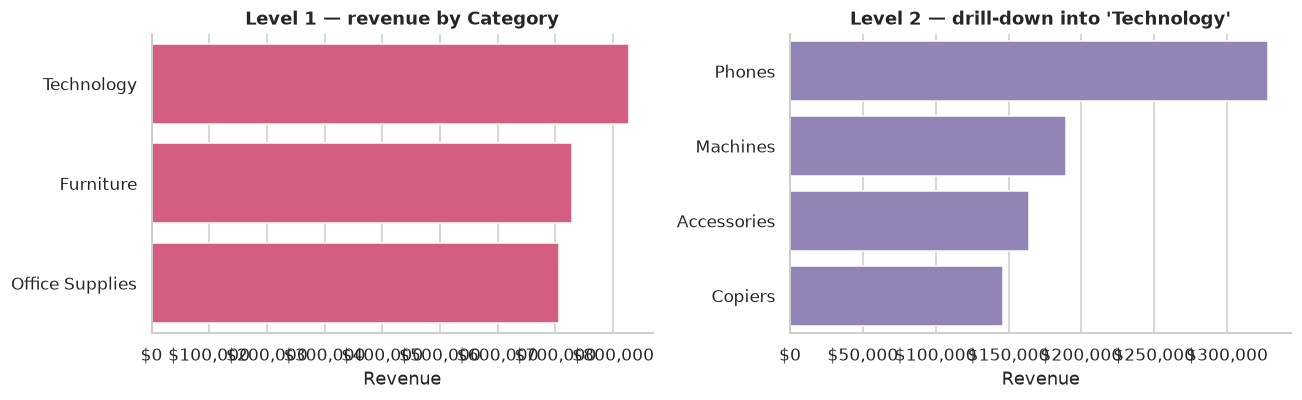

In [28]:
cat_totals = q("""SELECT p.category, ROUND(SUM(f.sales),0) AS revenue
                  FROM fact_sales f JOIN dim_product p ON f.product_key = p.product_key
                  GROUP BY p.category ORDER BY revenue DESC""")
top_cat = cat_totals.iloc[0]["category"]
sub_totals = q("""SELECT p.sub_category, ROUND(SUM(f.sales),0) AS revenue
                  FROM fact_sales f JOIN dim_product p ON f.product_key = p.product_key
                  WHERE p.category = ? GROUP BY p.sub_category ORDER BY revenue DESC""", (top_cat,))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.barplot(data=cat_totals, y="category", x="revenue", color=PALETTE[0], ax=axes[0])
axes[0].set(title="Level 1 — revenue by Category", ylabel="", xlabel="Revenue"); axes[0].xaxis.set_major_formatter(money)
sns.barplot(data=sub_totals, y="sub_category", x="revenue", color=PALETTE[1], ax=axes[1])
axes[1].set(title=f"Level 2 — drill-down into '{top_cat}'", ylabel="", xlabel="Revenue"); axes[1].xaxis.set_major_formatter(money)
plt.tight_layout(); plt.show()

**③ Slice** — fix one dimension (year = 2018) and look at the rest.  **④ Dice** — fix several at once.

In [29]:
slice_2018 = q("""SELECT g.region, ROUND(SUM(f.sales),0) AS revenue
                  FROM fact_sales f JOIN dim_date d ON f.order_date_key = d.date_key
                  JOIN dim_geography g ON f.geo_key = g.geo_key
                  WHERE d.year = 2018 GROUP BY g.region ORDER BY revenue DESC""")
print("SLICE — year = 2018, revenue by region")
display(slice_2018)

dice = q("""SELECT d.year, g.region, p.category, ROUND(SUM(f.sales),0) AS revenue
            FROM fact_sales f JOIN dim_date d ON f.order_date_key = d.date_key
            JOIN dim_geography g ON f.geo_key = g.geo_key
            JOIN dim_product p ON f.product_key = p.product_key
            WHERE g.region IN ('West','East') AND p.category IN ('Technology','Furniture') AND d.year IN (2017, 2018)
            GROUP BY d.year, g.region, p.category ORDER BY d.year, g.region, p.category""")
print("DICE — regions {West, East} × categories {Technology, Furniture} × years {2017, 2018}")
display(dice)

SLICE — year = 2018, revenue by region


,region,revenue
0,West,"248,131.00"
1,East,"210,129.00"
2,Central,"141,627.00"
3,South,"122,165.00"


DICE — regions {West, East} × categories {Technology, Furniture} × years {2017, 2018}


,year,region,category,revenue
0,2017,East,Furniture,"44,964.00"
1,2017,East,Technology,"72,497.00"
2,2017,West,Furniture,"73,241.00"
3,2017,West,Technology,"62,099.00"
4,2018,East,Furniture,"60,854.00"
5,2018,East,Technology,"86,120.00"
6,2018,West,Furniture,"71,029.00"
7,2018,West,Technology,"95,477.00"


**⑤ Pivot** — rotate Region into columns to make a cross-tab, with totals.

region,Central,East,South,West,TOTAL
category,,,,,
Furniture,"$160,317","$206,180","$116,531","$245,348","$728,377"
Office Supplies,"$163,590","$199,941","$124,425","$217,467","$705,422"
Technology,"$168,739","$263,117","$148,195","$247,405","$827,456"
TOTAL,"$492,647","$669,237","$389,151","$710,220","$2,261,255"


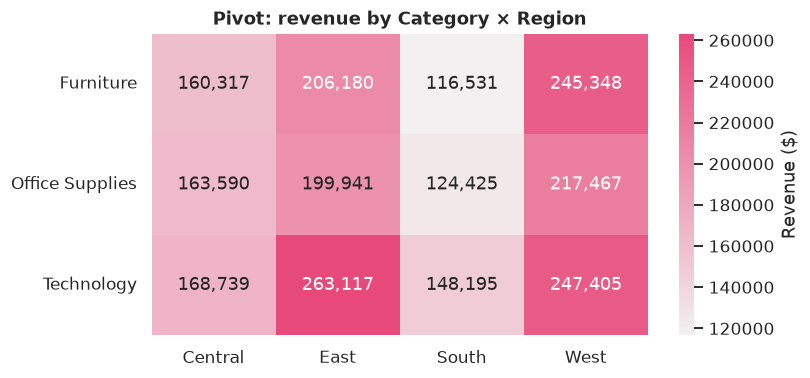

In [30]:
cr = q("""SELECT p.category, g.region, SUM(f.sales) AS revenue
          FROM fact_sales f JOIN dim_product p ON f.product_key = p.product_key
          JOIN dim_geography g ON f.geo_key = g.geo_key GROUP BY p.category, g.region""")
pivot = cr.pivot_table(index="category", columns="region", values="revenue", aggfunc="sum",
                       margins=True, margins_name="TOTAL").round(0)
display(pivot.style.format("${:,.0f}"))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
sns.heatmap(pivot.drop(index="TOTAL", columns="TOTAL"), annot=True, fmt=",.0f",
            cmap=sns.light_palette(PALETTE[0], as_cmap=True), cbar_kws={"label": "Revenue ($)"}, ax=ax)
ax.set(title="Pivot: revenue by Category × Region", xlabel="", ylabel="")
plt.tight_layout(); plt.show()

**⑥ Using the scraped data** — because population lives in `dim_geography`, one SQL join answers a question the original CSV never could: *which states buy the most **per resident**?*

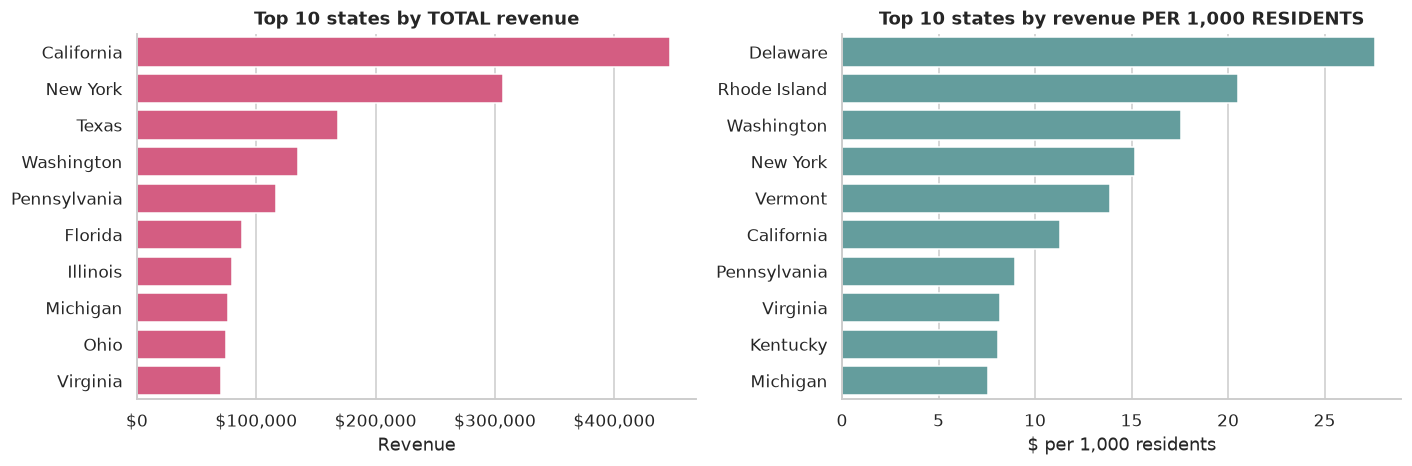

4 of the 10 best states per resident are NOT in the top-10 by total revenue: Delaware, Rhode Island, Vermont, Kentucky.
Total revenue favours big states; the per-resident view surfaces smaller states that punch above their weight.


In [31]:
percap = q("""SELECT g.state, ROUND(SUM(f.sales),0) AS revenue, MAX(g.state_population_2020) AS population,
                     ROUND(SUM(f.sales) * 1000.0 / MAX(g.state_population_2020), 2) AS revenue_per_1000_residents
              FROM fact_sales f JOIN dim_geography g ON f.geo_key = g.geo_key
              GROUP BY g.state ORDER BY revenue_per_1000_residents DESC""")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
t1 = percap.sort_values("revenue", ascending=False).head(10)
sns.barplot(data=t1, y="state", x="revenue", color=PALETTE[0], ax=axes[0])
axes[0].set(title="Top 10 states by TOTAL revenue", ylabel="", xlabel="Revenue"); axes[0].xaxis.set_major_formatter(money)
t2 = percap.head(10)
sns.barplot(data=t2, y="state", x="revenue_per_1000_residents", color=PALETTE[3], ax=axes[1])
axes[1].set(title="Top 10 states by revenue PER 1,000 RESIDENTS", ylabel="", xlabel="$ per 1,000 residents")
plt.tight_layout(); plt.show()

hidden = [s for s in t2["state"] if s not in set(t1["state"])]
print(f"{len(hidden)} of the 10 best states per resident are NOT in the top-10 by total revenue: {', '.join(hidden)}.")
print("Total revenue favours big states; the per-resident view surfaces smaller states that punch above their weight.")

**Why this matters:** the warehouse answered six different questions with simple `JOIN`s and `GROUP BY`s, never touching the raw CSV again, and the integrity checks guarantee the numbers agree with the source. That is the whole point of a star schema.

## 📊 5. Exploratory data analysis (EDA)

EDA means *looking before modelling*: understand each variable alone (univariate), then in pairs and groups (bivariate / multivariate), and form hypotheses for the mining steps.

### 5.1 Univariate — what does the data look like?

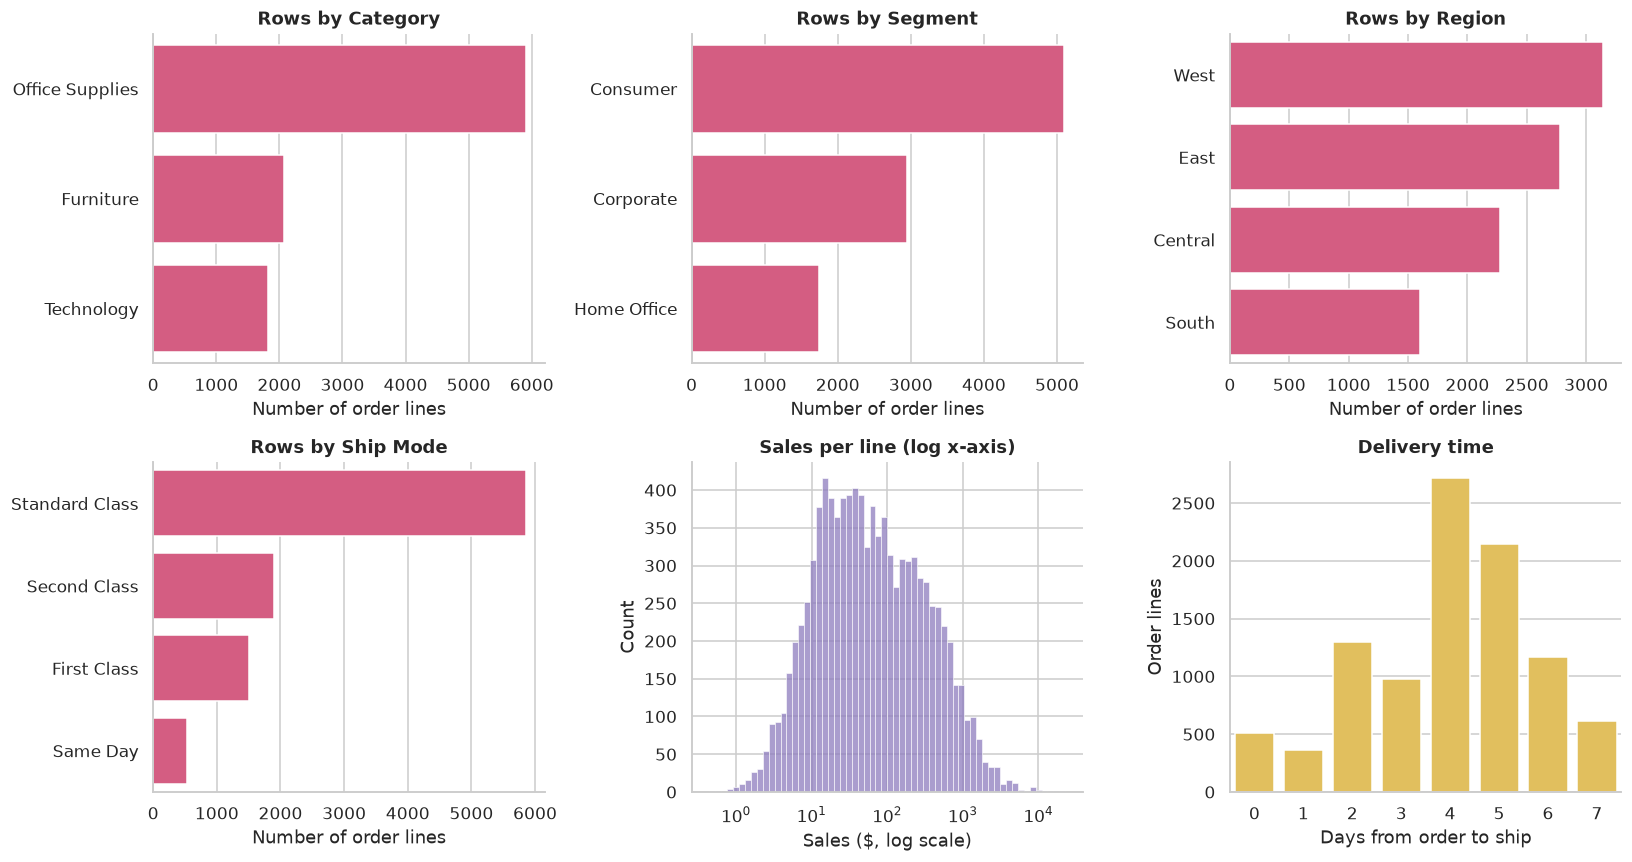

In [32]:
import matplotlib.dates as mdates
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat[:4], ["Category", "Segment", "Region", "Ship Mode"]):
    order = clean[col].value_counts().index
    sns.countplot(data=clean, y=col, order=order, color=PALETTE[0], ax=ax)
    ax.set(title=f"Rows by {col}", xlabel="Number of order lines", ylabel="")
sns.histplot(clean["Sales"], bins=60, log_scale=(True, False), ax=axes[1, 1], color=PALETTE[1])
axes[1, 1].set(title="Sales per line (log x-axis)", xlabel="Sales ($, log scale)")
sns.countplot(data=clean, x="ship_days", color=PALETTE[2], ax=axes[1, 2])
axes[1, 2].set(title="Delivery time", xlabel="Days from order to ship", ylabel="Order lines")
plt.tight_layout(); plt.show()

### 5.2 What sells? — revenue by product

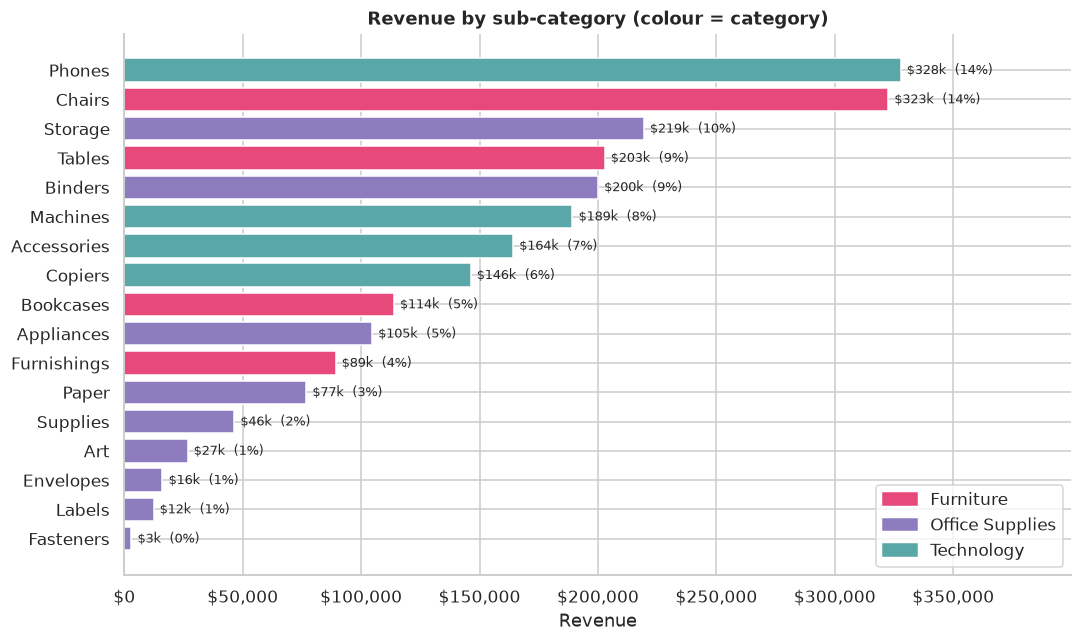

In [33]:
rev_sub = clean.groupby("Sub-Category")["Sales"].sum().sort_values()
cat_of = clean.drop_duplicates("Sub-Category").set_index("Sub-Category")["Category"]
cat_color = dict(zip(sorted(clean["Category"].unique()), [PALETTE[0], PALETTE[1], PALETTE[3]]))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(rev_sub.index, rev_sub.values, color=[cat_color[cat_of[s]] for s in rev_sub.index])
ax.bar_label(bars, labels=[f"${v/1000:,.0f}k  ({v/rev_sub.sum():.0%})" for v in rev_sub.values], padding=4, fontsize=8.5)
ax.xaxis.set_major_formatter(money); ax.set_xlim(0, rev_sub.max() * 1.22)
ax.set(title="Revenue by sub-category (colour = category)", xlabel="Revenue", ylabel="")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in cat_color.values()], labels=list(cat_color), loc="lower right")
plt.tight_layout(); plt.show()

### 5.3 When does it sell? — trends and seasonality

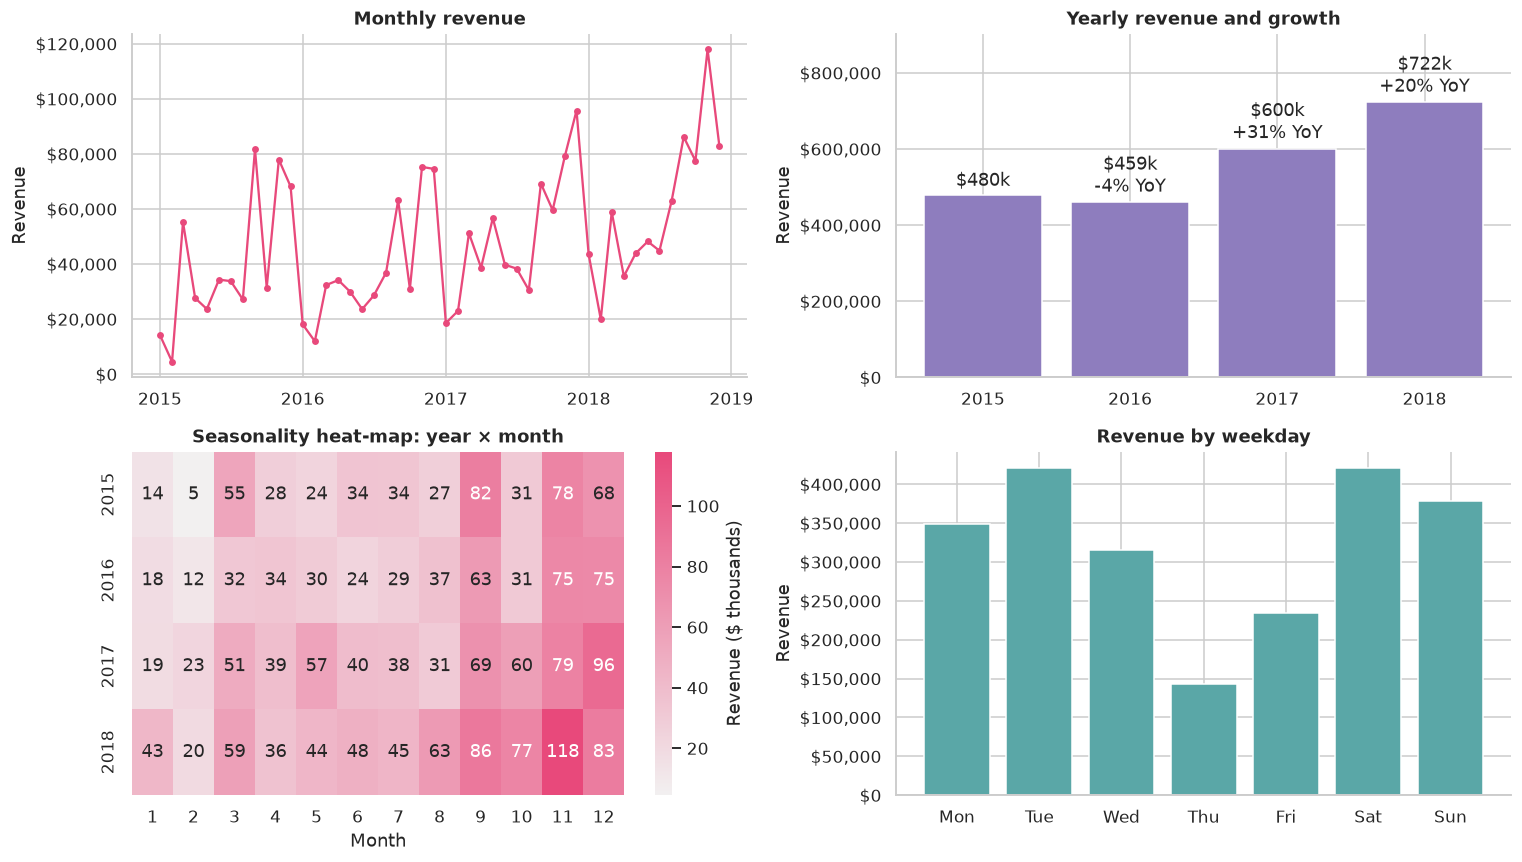

In [34]:
monthly = clean.set_index("Order Date")["Sales"].resample("MS").sum()
yearly = clean.groupby("order_year")["Sales"].sum()
piv = clean.pivot_table(index="order_year", columns="order_month", values="Sales", aggfunc="sum")
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
wd = clean.groupby("order_weekday")["Sales"].sum().reindex(weekday_order)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(monthly.index, monthly.values, marker="o", ms=3.5, color=PALETTE[0])
axes[0, 0].set(title="Monthly revenue", ylabel="Revenue"); axes[0, 0].yaxis.set_major_formatter(money)
axes[0, 0].xaxis.set_major_locator(mdates.YearLocator()); axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

bars = axes[0, 1].bar(yearly.index.astype(str), yearly.values, color=PALETTE[1])
growth = yearly.pct_change() * 100
axes[0, 1].bar_label(bars, labels=[f"${v/1000:,.0f}k" + ("" if np.isnan(g) else f"\n{g:+.0f}% YoY") for v, g in zip(yearly.values, growth)], padding=3)
axes[0, 1].set(title="Yearly revenue and growth", ylabel="Revenue"); axes[0, 1].yaxis.set_major_formatter(money)
axes[0, 1].set_ylim(0, yearly.max() * 1.25)

sns.heatmap(piv / 1000, annot=True, fmt=".0f", cmap=sns.light_palette(PALETTE[0], as_cmap=True), ax=axes[1, 0],
            cbar_kws={"label": "Revenue ($ thousands)"})
axes[1, 0].set(title="Seasonality heat-map: year × month", xlabel="Month", ylabel="")

axes[1, 1].bar(wd.index.str[:3], wd.values, color=PALETTE[3])
axes[1, 1].set(title="Revenue by weekday", ylabel="Revenue"); axes[1, 1].yaxis.set_major_formatter(money)
plt.tight_layout(); plt.show()

### 5.4 Who buys? — customers and the 80/20 rule

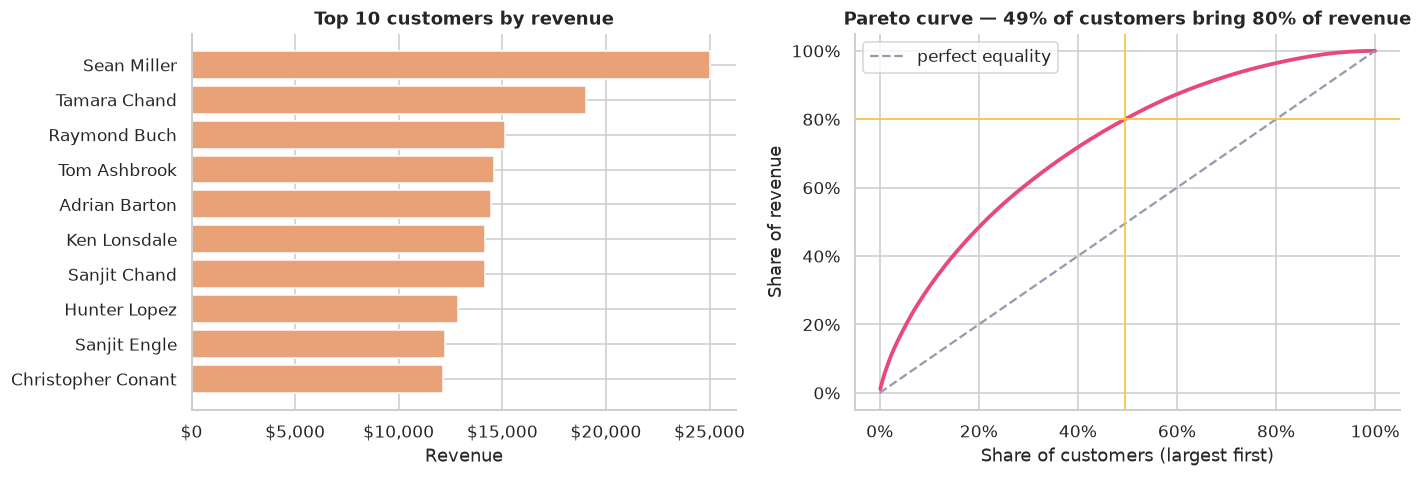

The top 20% of customers account for 48% of revenue.


In [35]:
cust = clean.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
cum = cust.cumsum() / cust.sum()
pct_for_80 = (cum <= 0.80).sum() / len(cust)
top20_share = cust.head(int(round(0.2 * len(cust)))).sum() / cust.sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
top10 = cust.head(10).sort_values()
axes[0].barh(top10.index, top10.values, color=PALETTE[5])
axes[0].xaxis.set_major_formatter(money); axes[0].set(title="Top 10 customers by revenue", xlabel="Revenue")
x = np.arange(1, len(cum) + 1) / len(cum)
axes[1].plot(x, cum.values, color=PALETTE[0], lw=2.5)
axes[1].plot([0, 1], [0, 1], "--", color="#9A9AAE", label="perfect equality")
axes[1].axhline(0.8, color=PALETTE[2], lw=1.2); axes[1].axvline(pct_for_80, color=PALETTE[2], lw=1.2)
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set(title=f"Pareto curve — {pct_for_80:.0%} of customers bring 80% of revenue",
            xlabel="Share of customers (largest first)", ylabel="Share of revenue"); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"The top 20% of customers account for {top20_share:.0%} of revenue.")

### 5.5 Relationships — what drives sales?

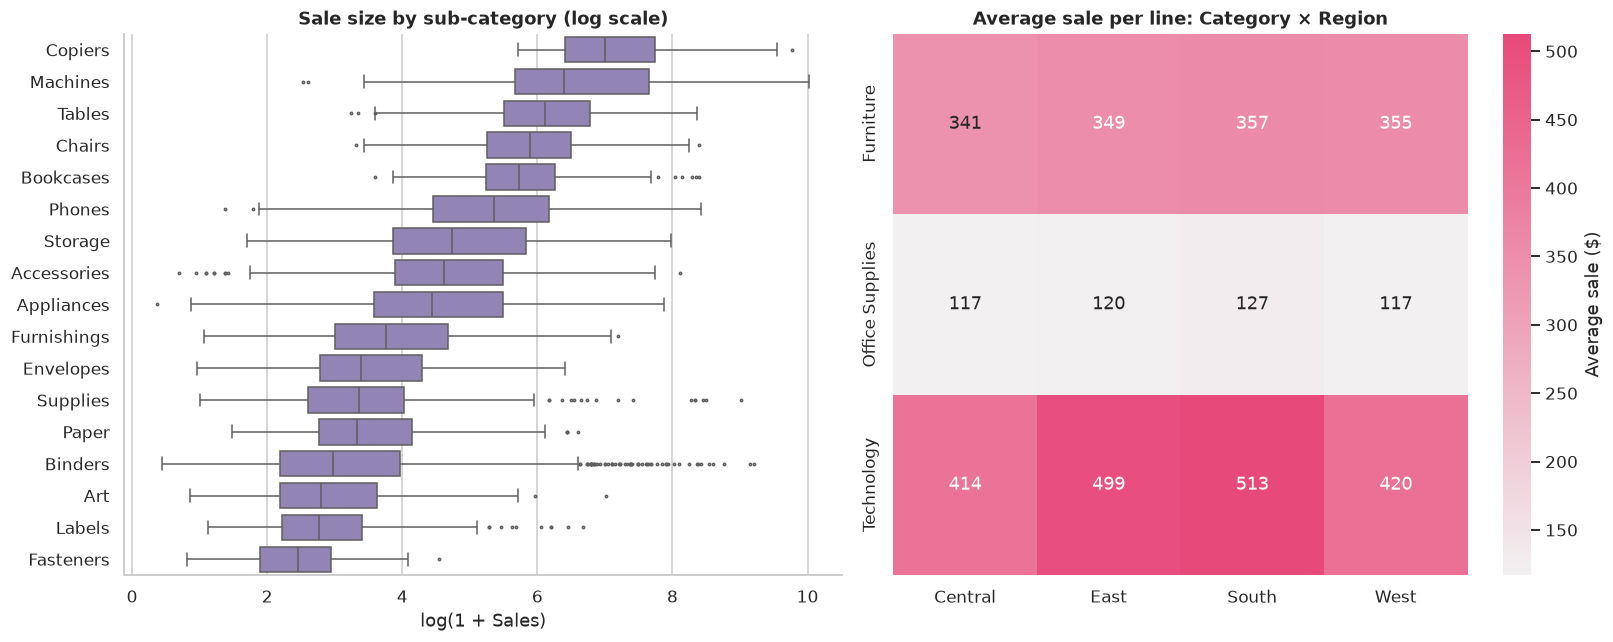

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
order = clean.groupby("Sub-Category")["log_sales"].median().sort_values(ascending=False).index
sns.boxplot(data=clean, y="Sub-Category", x="log_sales", order=order, color=PALETTE[1], fliersize=1.5, ax=axes[0])
axes[0].set(title="Sale size by sub-category (log scale)", xlabel="log(1 + Sales)", ylabel="")

avg = clean.pivot_table(index="Category", columns="Region", values="Sales", aggfunc="mean")
sns.heatmap(avg, annot=True, fmt=".0f", cmap=sns.light_palette(PALETTE[0], as_cmap=True), ax=axes[1],
            cbar_kws={"label": "Average sale ($)"})
axes[1].set(title="Average sale per line: Category × Region", xlabel="", ylabel="")
plt.tight_layout(); plt.show()

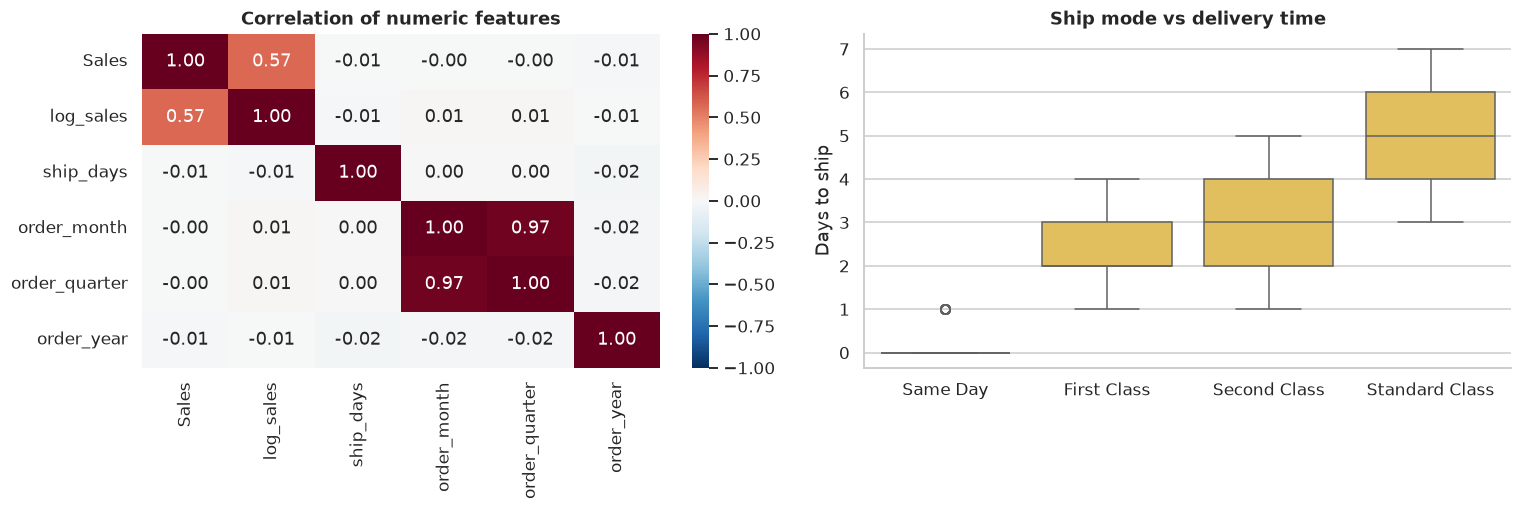

In [37]:
num_cols = ["Sales", "log_sales", "ship_days", "order_month", "order_quarter", "order_year"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.heatmap(clean[num_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set(title="Correlation of numeric features")
sns.boxplot(data=clean, x="Ship Mode", y="ship_days", order=["Same Day", "First Class", "Second Class", "Standard Class"],
            color=PALETTE[2], ax=axes[1])
axes[1].set(title="Ship mode vs delivery time", xlabel="", ylabel="Days to ship")
plt.tight_layout(); plt.show()

**Reading the relationships:** correlation among the numeric columns is weak — *when* or *how fast* something ships barely changes the sale size. What really separates a \$10 sale from a \$1,000 sale is **what** was bought (the sub-category box-plots barely overlap). This is a key hypothesis for the models: **product type will dominate the predictions.**

### 5.6 EDA summary — key findings

In [38]:
best_month = monthly.idxmax()
best_cat = clean.groupby("Category")["Sales"].sum().idxmax()
best_sub = rev_sub.idxmax()
best_region = clean.groupby("Region")["Sales"].sum().idxmax()
cagr = (yearly.iloc[-1] / yearly.iloc[0]) ** (1 / (len(yearly) - 1)) - 1
nov_dec = monthly[monthly.index.month.isin([11, 12])].sum() / monthly.sum()

print(f"1. Total revenue ${clean['Sales'].sum():,.0f} from {clean['Order ID'].nunique():,} orders and {clean['Customer ID'].nunique()} customers.")
print(f"2. Revenue grew from ${yearly.iloc[0]:,.0f} ({yearly.index[0]}) to ${yearly.iloc[-1]:,.0f} ({yearly.index[-1]}) — about {cagr:.0%} per year.")
print(f"3. Strong seasonality: November + December alone bring {nov_dec:.0%} of all revenue; best month ever = {best_month:%B %Y}.")
print(f"4. {best_cat} is the top category; {best_sub} the top sub-category; {best_region} the top region.")
print(f"5. Customer revenue is concentrated: top 20% of customers = {top20_share:.0%} of revenue.")
print(f"6. Sale size depends on the product, not on timing or shipping (weak numeric correlations).")

1. Total revenue $2,261,255 from 4,922 orders and 793 customers.
2. Revenue grew from $479,575 (2015) to $722,052 (2018) — about 15% per year.
3. Strong seasonality: November + December alone bring 30% of all revenue; best month ever = November 2018.
4. Technology is the top category; Phones the top sub-category; West the top region.
5. Customer revenue is concentrated: top 20% of customers = 48% of revenue.
6. Sale size depends on the product, not on timing or shipping (weak numeric correlations).


## 🎯 6. Classification

**Classification** predicts a *category* (a label) for each record. Business question:

> *Given an order line's product, customer segment, region, timing and shipping, will it be a **high-value sale**?*

Why it is useful: sales teams can prioritise the kinds of orders that generate the most revenue.

**Target definition:** `high_value = 1` if the line's sales are in the **top 25%** of all lines, else `0`. This gives an *imbalanced* problem (25% / 75%), so **accuracy alone is misleading** — predicting "not high-value" every time would already be 75% accurate. We therefore also report **precision, recall, F1 and ROC-AUC**.

**Features used:** Category, Sub-Category, Segment, Region, Ship Mode, order month / quarter / year, shipping days, and the **scraped state population**. We deliberately do *not* use anything derived from `Sales` itself (that would be leakage).

In [39]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             r2_score, mean_squared_error, mean_absolute_error)
from xgboost import XGBClassifier, XGBRegressor

# modelling table = clean data + the scraped population
mdl = clean.merge(state_pop.rename(columns={"state": "State", "population_2020": "state_pop"}), on="State", how="left")
mdl["state_pop_millions"] = mdl["state_pop"] / 1e6

CAT = ["Category", "Sub-Category", "Segment", "Region", "Ship Mode"]
NUM = ["order_month", "order_quarter", "order_year", "ship_days", "state_pop_millions"]
FEATURES = CAT + NUM
assert mdl[FEATURES].isna().sum().sum() == 0, "unexpected missing values in the features"

def make_preprocessor():
    # one-hot encode categories, standard-scale numbers — fitted ONLY on the training data inside each pipeline
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT),
        ("num", StandardScaler(), NUM),
    ])

threshold = clean["Sales"].quantile(0.75)
mdl["high_value"] = (mdl["Sales"] >= threshold).astype(int)
print(f"A line is 'high-value' if Sales ≥ ${threshold:,.2f}  →  {mdl['high_value'].mean():.1%} of lines")

X, y = mdl[FEATURES], mdl["high_value"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,} rows · Test: {len(X_test):,} rows (stratified, so both keep the 25/75 balance)")

A line is 'high-value' if Sales ≥ $210.57  →  25.0% of lines
Train: 7,839 rows · Test: 1,960 rows (stratified, so both keep the 25/75 balance)


In [40]:
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, min_samples_leaf=3, class_weight="balanced_subsample",
                                                  n_jobs=2, random_state=RANDOM_STATE),
    "KNN (k=15)":          KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes":         GaussianNB(),
    "XGBoost":             XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.08, subsample=0.9,
                                         colsample_bytree=0.9, scale_pos_weight=3, eval_metric="logloss",
                                         tree_method="hist", n_jobs=2, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows, fitted, probas = [], {}, {}
for name, model in classifiers.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", model)])
    cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1").mean()      # 5-fold CV on the training set
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    fitted[name], probas[name] = pipe, proba
    rows.append({"model": name, "accuracy": accuracy_score(y_test, pred), "precision": precision_score(y_test, pred),
                 "recall": recall_score(y_test, pred), "F1": f1_score(y_test, pred),
                 "ROC-AUC": roc_auc_score(y_test, proba), "CV F1 (5-fold)": cv_f1})

clf_results = pd.DataFrame(rows).set_index("model").sort_values("F1", ascending=False)
best_clf = clf_results.index[0]
baseline_acc = 1 - y_test.mean()
print(f"Reference: always guessing 'not high-value' would be {baseline_acc:.1%} accurate but useless (F1 = 0).")
clf_results.round(3)

Reference: always guessing 'not high-value' would be 75.0% accurate but useless (F1 = 0).


,accuracy,precision,recall,F1,ROC-AUC,CV F1 (5-fold)
model,,,,,,
Naive Bayes,0.76,0.51,0.83,0.63,0.85,0.62
Logistic Regression,0.74,0.49,0.84,0.62,0.85,0.62
Random Forest,0.78,0.54,0.71,0.62,0.85,0.63
XGBoost,0.75,0.50,0.79,0.62,0.85,0.63
Decision Tree,0.74,0.48,0.80,0.60,0.83,0.62
KNN (k=15),0.79,0.65,0.36,0.47,0.81,0.41


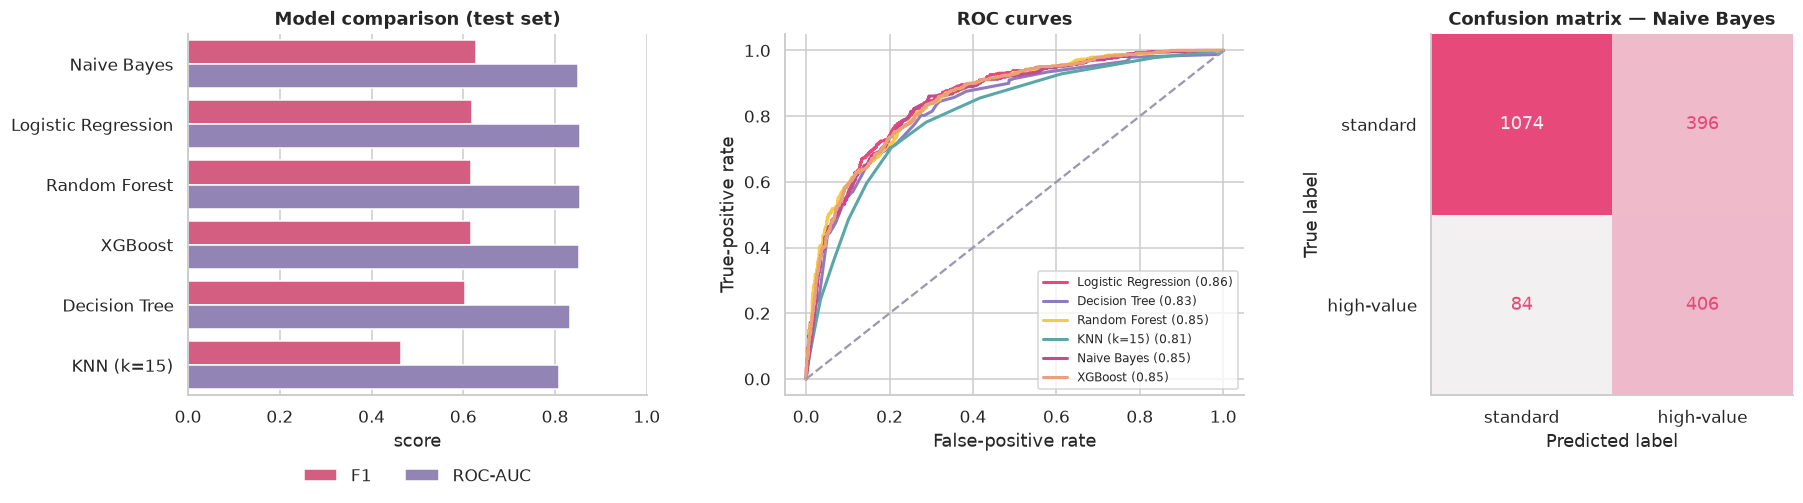

Naive Bayes: of 490 truly high-value lines it found 406 (83% recall); of 802 lines it flagged, 406 were right (51% precision).


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# (a) metric comparison
plot_df = clf_results[["F1", "ROC-AUC"]].reset_index().melt(id_vars="model", var_name="metric", value_name="score")
sns.barplot(data=plot_df, y="model", x="score", hue="metric", palette=[PALETTE[0], PALETTE[1]], ax=axes[0])
axes[0].set(title="Model comparison (test set)", xlabel="score", ylabel="", xlim=(0, 1))
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)

# (b) ROC curves
for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} ({roc_auc_score(y_test, p):.2f})")
axes[1].plot([0, 1], [0, 1], "--", color="#9A9AAE")
axes[1].set(title="ROC curves", xlabel="False-positive rate", ylabel="True-positive rate"); axes[1].legend(fontsize=8, loc="lower right")

# (c) confusion matrix of the best model
cm = confusion_matrix(y_test, fitted[best_clf].predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["standard", "high-value"]).plot(ax=axes[2], cmap=sns.light_palette(PALETTE[0], as_cmap=True), colorbar=False)
axes[2].set(title=f"Confusion matrix — {best_clf}"); axes[2].grid(False)
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"{best_clf}: of {tp + fn} truly high-value lines it found {tp} ({tp/(tp+fn):.0%} recall); "
      f"of {tp + fp} lines it flagged, {tp} were right ({tp/(tp+fp):.0%} precision).")

**How to read the metrics**
* **Precision** — of the lines we *flag* as high-value, how many truly are?
* **Recall** — of all truly high-value lines, how many do we *catch*?
* **F1** — the balance of the two (best single number for imbalanced data).
* **ROC-AUC** — how well the model *ranks* high-value above standard lines (0.5 = coin flip, 1.0 = perfect).
* **CV F1** — the same F1 averaged over 5 different train/validation splits; if it is close to the test F1 the model is **not overfitted**.

### 6.1 Which features matter?
Random Forests measure how much each feature reduces impurity. Because one-hot encoding splits a category like Sub-Category into 17 columns, we **add them back together** to get one importance per original feature.

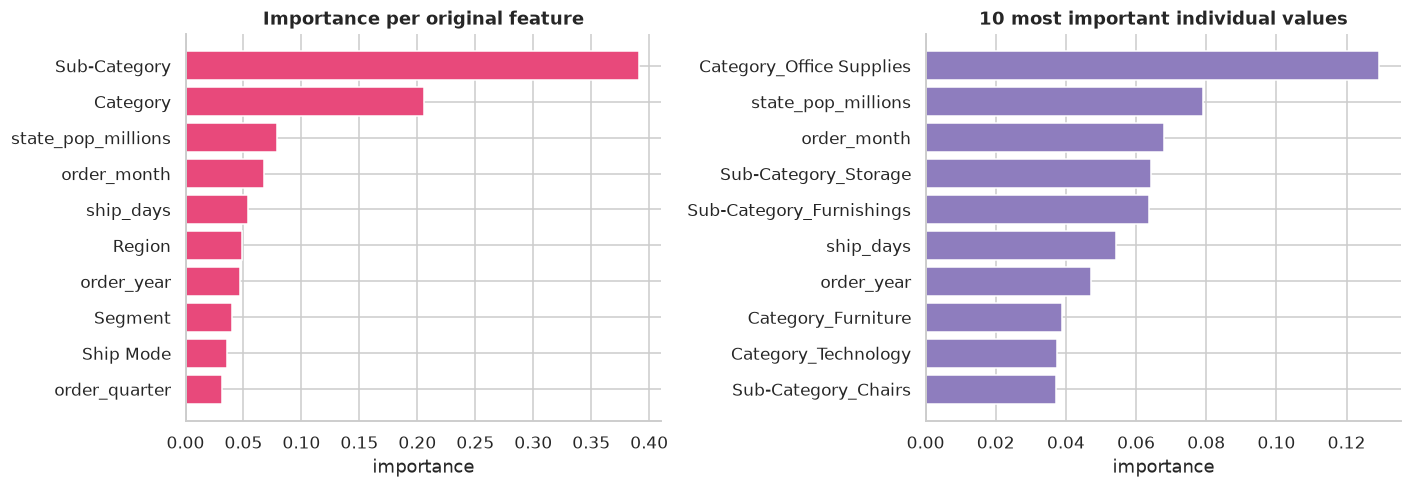

Most important feature: 'Sub-Category' (39% of total importance).


In [42]:
rf_pipe = fitted["Random Forest"]
enc_names = list(rf_pipe.named_steps["prep"].get_feature_names_out())
importances = rf_pipe.named_steps["model"].feature_importances_

def original_feature(encoded_name):
    n = encoded_name.split("__", 1)[1]
    for c in CAT:
        if n.startswith(c + "_"):
            return c
    return n

grouped = pd.Series(importances, index=[original_feature(n) for n in enc_names]).groupby(level=0).sum().sort_values()
top_enc = pd.Series(importances, index=[n.split("__", 1)[1] for n in enc_names]).sort_values().tail(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].barh(grouped.index, grouped.values, color=PALETTE[0]); axes[0].set(title="Importance per original feature", xlabel="importance")
axes[1].barh(top_enc.index, top_enc.values, color=PALETTE[1]); axes[1].set(title="10 most important individual values", xlabel="importance")
plt.tight_layout(); plt.show()
print(f"Most important feature: '{grouped.index[-1]}' ({grouped.iloc[-1]:.0%} of total importance).")

### 6.2 A readable decision tree
A depth-3 tree is easy to read and shows the *rules* the algorithm discovered.

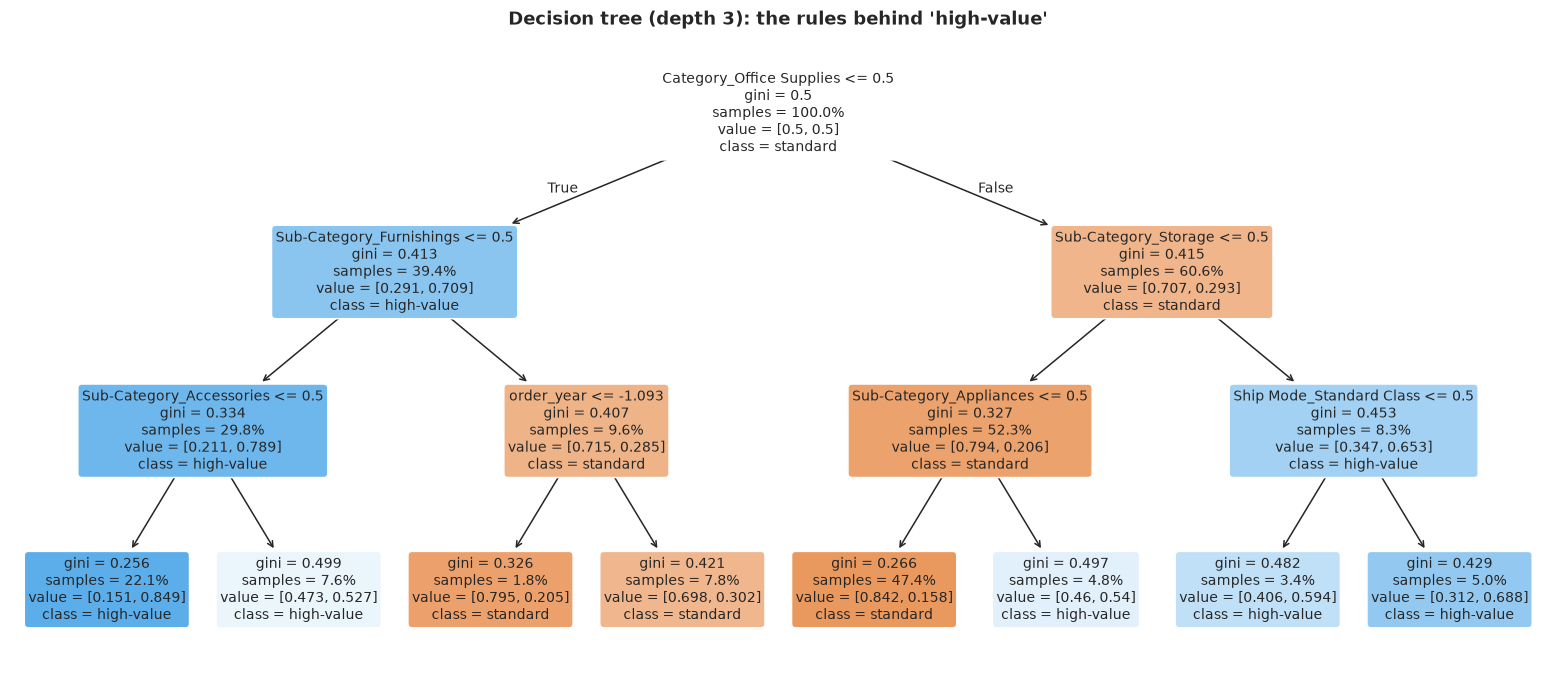

|--- Category_Office Supplies <= 0.50
|   |--- Sub-Category_Furnishings <= 0.50
|   |   |--- Sub-Category_Accessories <= 0.50
|   |   |   |--- class: 1
|   |   |--- Sub-Category_Accessories >  0.50
|   |   |   |--- class: 1
|   |--- Sub-Category_Furnishings >  0.50
|   |   |--- order_year <= -1.09
|   |   |   |--- class: 0
|   |   |--- order_year >  -1.09
|   |   |   |--- class: 0
|--- Category_Office Supplies >  0.50
|   |--- Sub-Category_Storage <= 0.50
|   |   |--- Sub-Category_Appliances <= 0.50
|   |   |   |--- class: 0
|   |   |--- Sub-Category_Appliances >  0.50
|   |   |   |--- class: 1
|   |--- Sub-Category_Storage >  0.50
|   |   |--- Ship Mode_Standard Class <= 0.50
|   |   |   |--- class: 1
|   |   |--- Ship Mode_Standard Class >  0.50
|   |   |   |--- class: 1



In [43]:
prep = make_preprocessor().fit(X_train)
Xt = prep.transform(X_train)
names_clean = [n.split("__", 1)[1] for n in prep.get_feature_names_out()]
small_tree = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=RANDOM_STATE).fit(Xt, y_train)

fig, ax = plt.subplots(figsize=(18, 7.5))
plot_tree(small_tree, feature_names=names_clean, class_names=["standard", "high-value"], filled=True, rounded=True,
          proportion=True, fontsize=9, ax=ax)
ax.set_title("Decision tree (depth 3): the rules behind 'high-value'")
plt.show()
print(export_text(small_tree, feature_names=names_clean, max_depth=3)[:1500])

### 6.3 Hyper-parameter tuning
We tune the Random Forest with **grid search + 3-fold cross-validation** (it tries every combination below and keeps the best by F1), then compare against the untuned version on the untouched test set.

In [44]:
grid = GridSearchCV(
    Pipeline([("prep", make_preprocessor()),
              ("model", RandomForestClassifier(n_estimators=150, class_weight="balanced_subsample", n_jobs=2, random_state=RANDOM_STATE))]),
    param_grid={"model__max_depth": [None, 12], "model__min_samples_leaf": [1, 3, 5]},
    scoring="f1", cv=3, n_jobs=1)
grid.fit(X_train, y_train)
tuned_f1 = f1_score(y_test, grid.predict(X_test))
print("Best parameters:", grid.best_params_)
print(f"Random Forest F1 on the test set — untuned: {clf_results.loc['Random Forest', 'F1']:.3f} · tuned: {tuned_f1:.3f}")

Best parameters: {'model__max_depth': 12, 'model__min_samples_leaf': 5}
Random Forest F1 on the test set — untuned: 0.616 · tuned: 0.621


### 6.4 Classification — conclusion

In [45]:
top_feat = grouped.index[-1]
tied = [m for m in clf_results.index if clf_results.loc[best_clf, "F1"] - clf_results.loc[m, "F1"] <= 0.015]
print(f"• Top F1: {best_clf} ({clf_results.loc[best_clf, 'F1']:.2f}, ROC-AUC {clf_results.loc[best_clf, 'ROC-AUC']:.2f}).")
print(f"• But {len(tied)} models are within 0.015 F1 of each other ({', '.join(tied)}) — that is a statistical tie, not a winner.")
print("  When models tie, prefer the one that is easiest to explain: the Random Forest / Decision Tree give feature importances and readable rules.")
print(f"• KNN is clearly weakest (recall {clf_results.loc['KNN (k=15)', 'recall']:.2f}): distance-based methods struggle with many one-hot columns and the 25/75 imbalance.")
print(f"• '{top_feat}' is the dominant driver, confirming the EDA hypothesis: WHAT is bought decides the sale size.")
gap = clf_results.loc[best_clf, 'F1'] - clf_results.loc[best_clf, 'CV F1 (5-fold)']
print(f"• CV F1 vs test F1 differ by only {abs(gap):.2f} → the model generalises, it is not memorising.")
print("• Business use: flag incoming orders likely to be high-value for priority handling / account-manager attention.")

• Top F1: Naive Bayes (0.63, ROC-AUC 0.85).
• But 4 models are within 0.015 F1 of each other (Naive Bayes, Logistic Regression, Random Forest, XGBoost) — that is a statistical tie, not a winner.
  When models tie, prefer the one that is easiest to explain: the Random Forest / Decision Tree give feature importances and readable rules.
• KNN is clearly weakest (recall 0.36): distance-based methods struggle with many one-hot columns and the 25/75 imbalance.
• 'Sub-Category' is the dominant driver, confirming the EDA hypothesis: WHAT is bought decides the sale size.
• CV F1 vs test F1 differ by only 0.00 → the model generalises, it is not memorising.
• Business use: flag incoming orders likely to be high-value for priority handling / account-manager attention.


## 📈 7. Regression

**Regression** predicts a *number*. Two tasks:

1. **7.1 — predict the sale value of an order line** from its attributes.
2. **7.2 — forecast total monthly revenue** into the future (time-series regression).

### 7.1 Predicting the sale value
We predict `log(1 + Sales)` (explained in pre-processing: it removes the skew, so errors are measured in *relative* rather than dollar terms) and compare five regressors against a **do-nothing baseline** that always predicts the average.

Metrics: **R²** (share of variance explained; 0 = no better than the average, 1 = perfect), **RMSE / MAE** (typical error size).

In [46]:
yr = mdl["log_sales"]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X, yr, test_size=0.2, random_state=RANDOM_STATE)

regressors = {
    "Baseline (always the mean)": DummyRegressor(strategy="mean"),
    "Linear Regression":  LinearRegression(),
    "Ridge (alpha=1)":    Ridge(alpha=1.0),
    "Decision Tree":      DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=RANDOM_STATE),
    "Random Forest":      RandomForestRegressor(n_estimators=250, min_samples_leaf=3, n_jobs=2, random_state=RANDOM_STATE),
    "XGBoost":            XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9,
                                       colsample_bytree=0.9, tree_method="hist", n_jobs=2, random_state=RANDOM_STATE),
}
rows, reg_fitted, reg_pred = [], {}, {}
for name, model in regressors.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", model)]).fit(Xr_train, yr_train)
    pred = pipe.predict(Xr_test)
    reg_fitted[name], reg_pred[name] = pipe, pred
    rows.append({"model": name, "R²": r2_score(yr_test, pred),
                 "RMSE (log)": np.sqrt(mean_squared_error(yr_test, pred)),
                 "MAE (log)": mean_absolute_error(yr_test, pred),
                 "MAE ($)": mean_absolute_error(np.expm1(yr_test), np.expm1(pred))})

reg_results = pd.DataFrame(rows).set_index("model").sort_values("R²", ascending=False)
best_reg = reg_results.index[0]
reg_results.round(3)

,R²,RMSE (log),MAE (log),MAE ($)
model,,,,
XGBoost,0.46,1.20,0.94,195.03
Linear Regression,0.44,1.21,0.96,195.25
Ridge (alpha=1),0.44,1.21,0.96,195.17
Random Forest,0.43,1.22,0.96,196.71
Decision Tree,0.42,1.24,0.97,197.34
Baseline (always the mean),-0.00,1.62,1.34,229.85


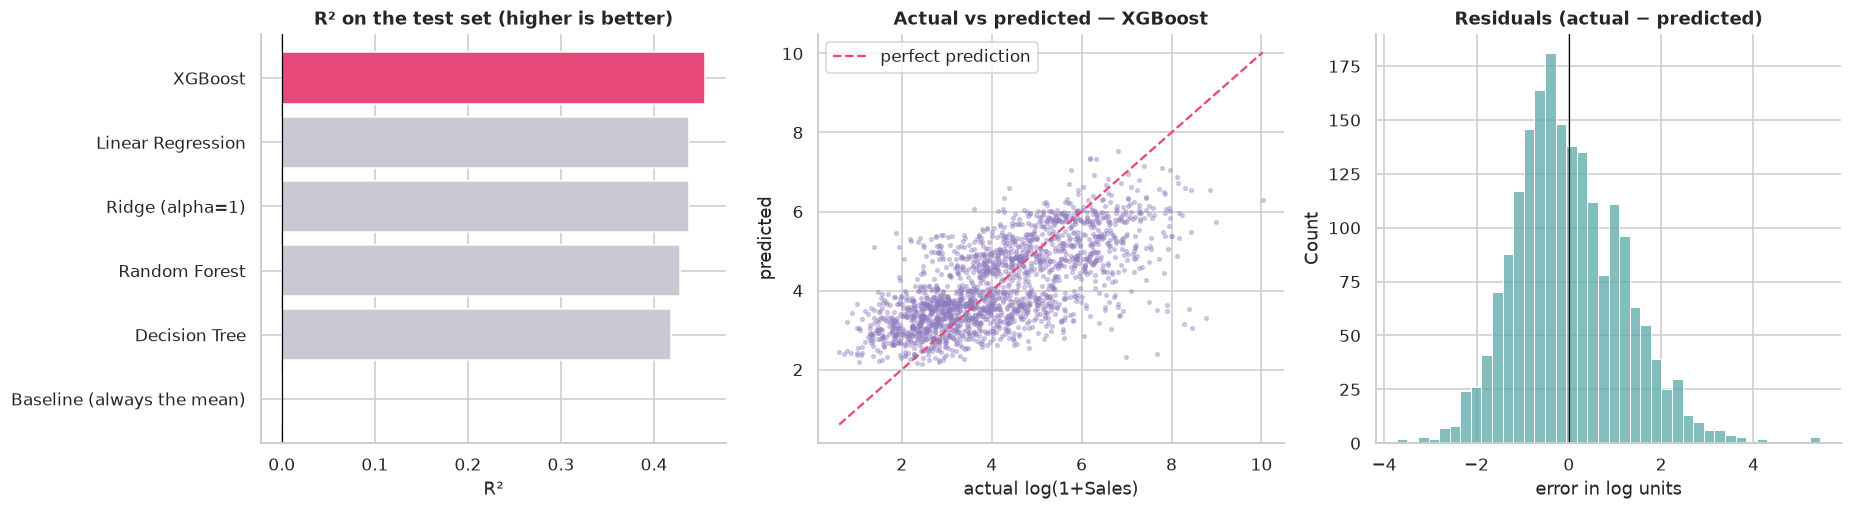

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
r2_plot = reg_results["R²"].sort_values()
axes[0].barh(r2_plot.index, r2_plot.values, color=[PALETTE[0] if n == best_reg else "#C9C9D6" for n in r2_plot.index])
axes[0].set(title="R² on the test set (higher is better)", xlabel="R²"); axes[0].axvline(0, color="black", lw=0.8)

axes[1].scatter(yr_test, reg_pred[best_reg], s=6, alpha=0.35, color=PALETTE[1])
lims = [yr_test.min(), yr_test.max()]
axes[1].plot(lims, lims, "--", color=PALETTE[0], label="perfect prediction")
axes[1].set(title=f"Actual vs predicted — {best_reg}", xlabel="actual log(1+Sales)", ylabel="predicted"); axes[1].legend()

resid = yr_test - reg_pred[best_reg]
sns.histplot(resid, bins=40, color=PALETTE[3], ax=axes[2])
axes[2].axvline(0, color="black", lw=0.8); axes[2].set(title="Residuals (actual − predicted)", xlabel="error in log units")
plt.tight_layout(); plt.show()

In [48]:
best_r2 = reg_results.loc[best_reg, "R²"]
print(f"Best regressor: {best_reg} with R² = {best_r2:.2f} → the features explain about {best_r2:.0%} of the variation in (log) sale size.")
base_mae = reg_results.loc["Baseline (always the mean)", "MAE ($)"]
print(f"In dollars, the average miss falls from ${base_mae:,.0f} (baseline) to ${reg_results.loc[best_reg, 'MAE ($)']:,.0f} — a "
      f"{1 - reg_results.loc[best_reg, 'MAE ($)'] / base_mae:.0%} improvement; in log terms the typical error is a factor of "
      f"{np.exp(reg_results.loc[best_reg, 'MAE (log)']):.1f}×.")
tied_r = [m for m in reg_results.index if m != "Baseline (always the mean)" and best_r2 - reg_results.loc[m, "R²"] <= 0.04]
print(f"{len(tied_r)} models score within 0.04 R² of each other ({', '.join(tied_r)}) — even simple Linear Regression keeps up, "
      "which tells us the limit is the information in the features, not the algorithm.")

Best regressor: XGBoost with R² = 0.45 → the features explain about 45% of the variation in (log) sale size.
In dollars, the average miss falls from $230 (baseline) to $195 — a 15% improvement; in log terms the typical error is a factor of 2.6×.
5 models score within 0.04 R² of each other (XGBoost, Linear Regression, Ridge (alpha=1), Random Forest, Decision Tree) — even simple Linear Regression keeps up, which tells us the limit is the information in the features, not the algorithm.


**Honest interpretation.** The score is *moderate, not high — and that is expected*, not a bug. Our dataset has **no quantity, discount or exact product price**, which are exactly the things that determine a line's sale value. Product type alone tells us roughly *how big* a sale tends to be but not *the exact value*. The model beats the baseline clearly (R² well above 0), so the features carry real signal; the rest is unobserved information. In a real warehouse we would add quantity and unit price to the fact table.

### 7.2 Forecasting monthly revenue (time-series regression)
Here the target is *total revenue per month*, and the goal is to look **forward**. Two very different model families are compared:

| Model | Idea |
|---|---|
| **SARIMA** | Classical statistics: learns trend + yearly seasonality directly from the series |
| **XGBoost** | Machine learning on engineered features: month, quarter, last month's revenue (*lag-1*), last year's same month (*lag-12*), rolling mean |

**Evaluation rule for time series:** never shuffle. We train on the first ~80% of months and test on the *last* ~20% — the model never sees the future it is asked to predict. Both models forecast the whole test window **recursively** (each prediction feeds the next), so the comparison is fair.

In [49]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

ts = clean.set_index("Order Date")["Sales"].resample("MS").sum().astype(float)
TS_FEATS = ["year", "month", "quarter", "lag_1", "lag_2", "lag_3", "lag_12", "roll_mean_3", "roll_std_3"]

def ts_features(s):
    f = pd.DataFrame({"y": s})
    f["year"], f["month"], f["quarter"] = f.index.year, f.index.month, f.index.quarter
    for lag in (1, 2, 3, 12):
        f[f"lag_{lag}"] = f["y"].shift(lag)
    f["roll_mean_3"] = f["y"].shift(1).rolling(3).mean()
    f["roll_std_3"] = f["y"].shift(1).rolling(3).std()
    return f.dropna()

def ts_row(hist, ts_):
    return {"year": ts_.year, "month": ts_.month, "quarter": ts_.quarter, "lag_1": hist[-1], "lag_2": hist[-2],
            "lag_3": hist[-3], "lag_12": hist[-12], "roll_mean_3": float(np.mean(hist[-3:])),
            "roll_std_3": float(np.std(hist[-3:], ddof=1))}

def fit_xgb_ts(frame):
    m = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9,
                     tree_method="hist", n_jobs=2, random_state=RANDOM_STATE)
    return m.fit(frame[TS_FEATS], frame["y"])

def recursive_forecast(model, history, index):
    hist, out = [float(v) for v in history.to_numpy()], []
    for ts_ in index:
        yhat = float(model.predict(pd.DataFrame([ts_row(hist, ts_)])[TS_FEATS])[0])
        out.append(yhat); hist.append(yhat)
    return np.array(out)

def sarima_fit(series):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SARIMAX(series, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False, maxiter=50)

def ts_metrics(actual, pred):
    actual, pred = np.asarray(actual), np.asarray(pred)
    return {"RMSE": float(np.sqrt(np.mean((actual - pred) ** 2))), "MAE": float(np.mean(np.abs(actual - pred))),
            "MAPE %": float(np.mean(np.abs((actual - pred) / actual)) * 100)}

feats_ts = ts_features(ts)
split = int(round(len(feats_ts) * 0.8))
train_ts, test_ts = feats_ts.iloc[:split], feats_ts.iloc[split:]
series_train, series_test = ts[ts.index < test_ts.index[0]], ts[ts.index >= test_ts.index[0]]

xgb_bt = recursive_forecast(fit_xgb_ts(train_ts), series_train, series_test.index)
sar_bt = np.asarray(sarima_fit(series_train).get_forecast(steps=len(series_test)).predicted_mean)

ts_results = pd.DataFrame({"XGBoost": ts_metrics(series_test, xgb_bt), "SARIMA": ts_metrics(series_test, sar_bt)}).T
best_ts = ts_results["MAPE %"].idxmin()
print(f"Training months: {len(series_train)} · test months: {len(series_test)} ({series_test.index[0]:%b %Y} – {series_test.index[-1]:%b %Y})")
ts_results.round(1)

Training months: 41 · test months: 7 (Jun 2018 – Dec 2018)


,RMSE,MAE,MAPE %
XGBoost,"20,084.40","15,445.50",19.60
SARIMA,"25,215.70","21,562.40",29.10


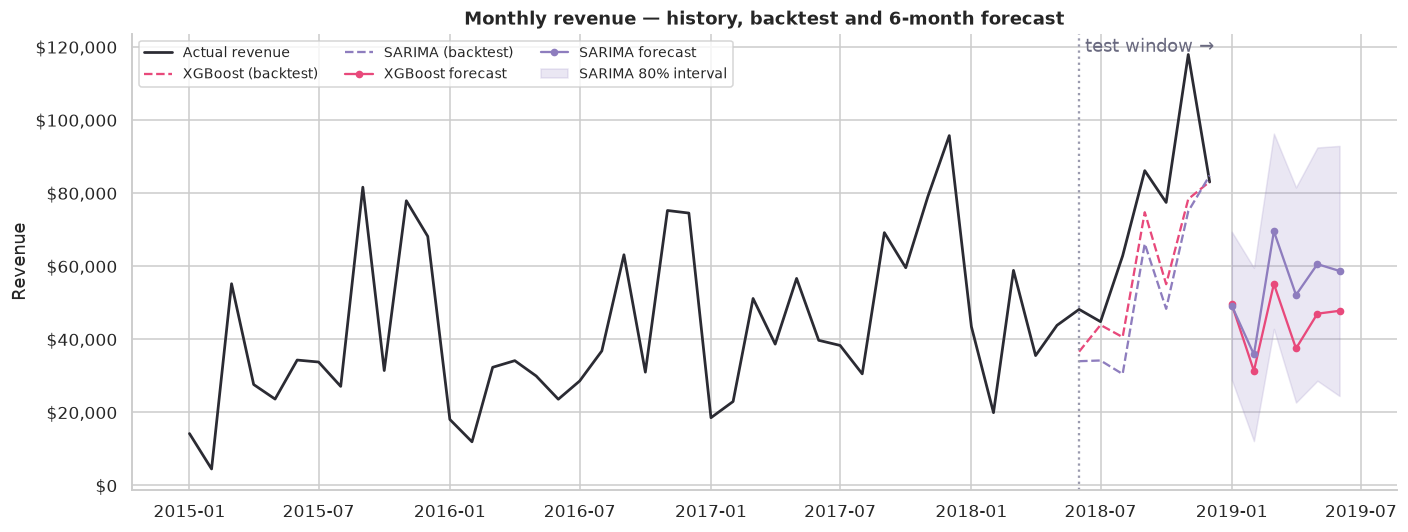

Best model on the backtest: XGBoost (MAPE 19.6%).
Forecast for Jan 2019 – Jun 2019: $268,370  vs $249,820 in the same months a year earlier (+7%).


In [50]:
# refit on ALL data and forecast the next 6 months
horizon = 6
future_idx = pd.date_range(ts.index[-1], periods=horizon + 1, freq="MS")[1:]
xgb_future = recursive_forecast(fit_xgb_ts(feats_ts), ts, future_idx)
sar_res = sarima_fit(ts)
sar_fc = sar_res.get_forecast(steps=horizon)
sar_future, sar_ci = np.asarray(sar_fc.predicted_mean), sar_fc.conf_int(alpha=0.2).to_numpy()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ts.index, ts.values, color="#2B2B33", lw=1.8, label="Actual revenue")
ax.plot(series_test.index, xgb_bt, "--", color=PALETTE[0], label="XGBoost (backtest)")
ax.plot(series_test.index, sar_bt, "--", color=PALETTE[1], label="SARIMA (backtest)")
ax.plot(future_idx, xgb_future, "-o", ms=4, color=PALETTE[0], label="XGBoost forecast")
ax.plot(future_idx, sar_future, "-o", ms=4, color=PALETTE[1], label="SARIMA forecast")
ax.fill_between(future_idx, sar_ci[:, 0], sar_ci[:, 1], color=PALETTE[1], alpha=0.18, label="SARIMA 80% interval")
ax.axvline(series_test.index[0], color="#9A9AAE", ls=":"); ax.text(series_test.index[0], ax.get_ylim()[1] * 0.96, " test window →", color="#6A6A80")
ax.yaxis.set_major_formatter(money)
ax.set(title="Monthly revenue — history, backtest and 6-month forecast", ylabel="Revenue"); ax.legend(ncol=3, fontsize=9, loc="upper left")
plt.tight_layout(); plt.show()

winner_future = xgb_future if best_ts == "XGBoost" else sar_future
# Compare with the SAME months a year earlier — comparing Jan–Jun with the preceding Jul–Dec would just show seasonality
same_months_last_year = ts.reindex(future_idx - pd.DateOffset(years=1)).sum()
print(f"Best model on the backtest: {best_ts} (MAPE {ts_results.loc[best_ts, 'MAPE %']:.1f}%).")
print(f"Forecast for {future_idx[0]:%b %Y} – {future_idx[-1]:%b %Y}: ${winner_future.sum():,.0f}  vs ${same_months_last_year:,.0f} "
      f"in the same months a year earlier ({(winner_future.sum() / same_months_last_year - 1):+.0%}).")

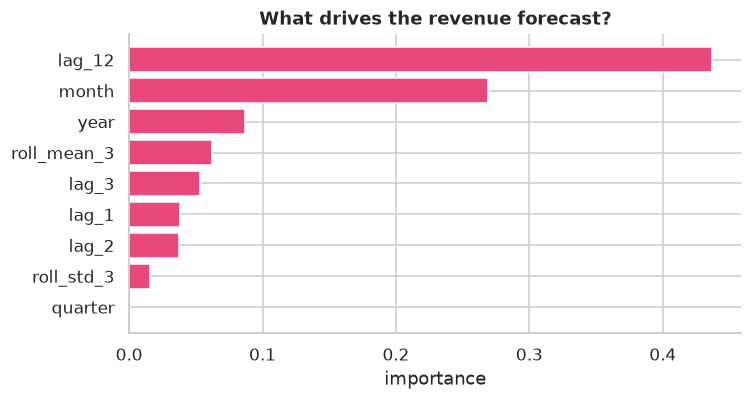

Top driver: 'lag_12' — last year's same month, i.e. strong yearly seasonality.


In [51]:
# Why does the forecast look the way it does? XGBoost's own feature importance
ts_model = fit_xgb_ts(feats_ts)
imp_ts = pd.Series(ts_model.feature_importances_, index=TS_FEATS).sort_values()
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(imp_ts.index, imp_ts.values, color=PALETTE[0]); ax.set(title="What drives the revenue forecast?", xlabel="importance")
plt.tight_layout(); plt.show()
print(f"Top driver: '{imp_ts.index[-1]}' — " + ("last year's same month, i.e. strong yearly seasonality." if imp_ts.index[-1] == "lag_12" else "see chart."))

## 🧩 8. Clustering

**Clustering** is *unsupervised*: there is no label to predict — the algorithm groups similar records on its own. Business question:

> *Which kinds of customers do we have, and how should we treat each group?*

We use the classic **RFM** representation of a customer:

| Letter | Meaning | Good customer = |
|---|---|---|
| **R**ecency | days since the last order | low |
| **F**requency | number of orders | high |
| **M**onetary | total money spent | high |

In [52]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram

snapshot = clean["Order Date"].max() + pd.Timedelta(days=1)
rfm = clean.groupby("Customer ID").agg(
    recency=("Order Date", lambda s: (snapshot - s.max()).days),
    frequency=("Order ID", "nunique"),
    monetary=("Sales", "sum"),
)
print(f"{len(rfm)} customers · analysis date = {snapshot:%d %b %Y}")
rfm.describe().round(1)

793 customers · analysis date = 31 Dec 2018


,recency,frequency,monetary
count,793.00,793.00,793.00
mean,149.30,6.20,"2,851.50"
std,187.10,2.50,"2,620.40"
min,1.00,1.00,4.80
25%,31.00,4.00,"1,081.50"
50%,76.00,6.00,"2,215.00"
75%,185.00,8.00,"3,670.30"
max,"1,166.00",17.00,"25,043.00"


### 8.1 Preparing the features
Distance-based algorithms are sensitive to scale and skew (monetary is in thousands, frequency in single digits, and all three are right-skewed). So: **log-transform, then standardise** — the same lesson as in pre-processing.

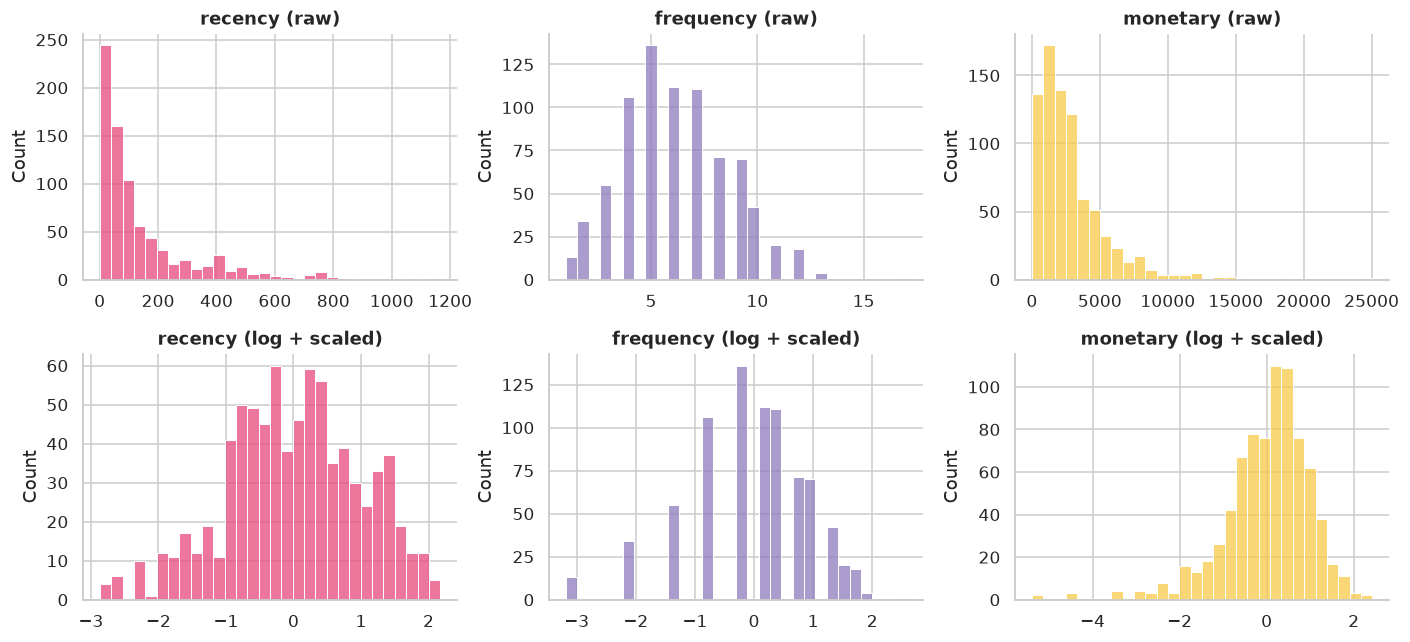

In [53]:
X_rfm = StandardScaler().fit_transform(np.log1p(rfm))

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for j, col in enumerate(["recency", "frequency", "monetary"]):
    sns.histplot(rfm[col], bins=30, ax=axes[0, j], color=PALETTE[j]); axes[0, j].set(title=f"{col} (raw)", xlabel="")
    sns.histplot(X_rfm[:, j], bins=30, ax=axes[1, j], color=PALETTE[j]); axes[1, j].set(title=f"{col} (log + scaled)", xlabel="")
plt.tight_layout(); plt.show()

### 8.2 Choosing the number of clusters (k)
K-Means needs k in advance. We do not guess — we measure three criteria for k = 2…8:

* **Elbow (inertia)** — total squared distance to the centroids; look for the "bend" where adding clusters stops helping much.
* **Silhouette score** — how well each point fits its own cluster vs the next-nearest (−1…1, **higher** is better).
* **Davies–Bouldin index** — average cluster overlap (**lower** is better).

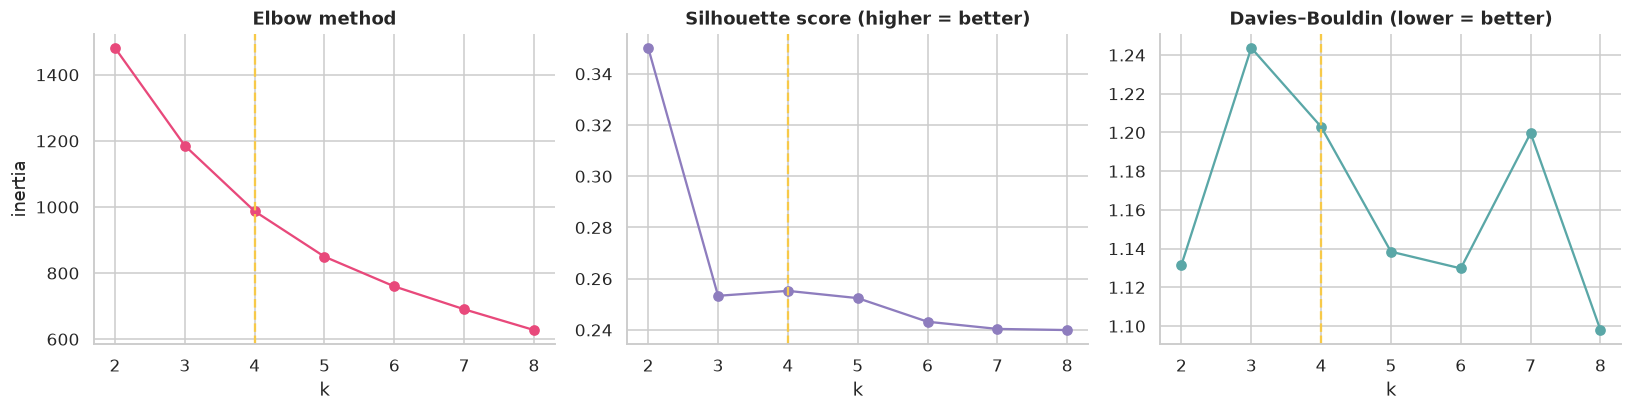

Chosen k = 4 (best silhouette = 0.26 among k = 3…6).


,k,inertia,silhouette,davies_bouldin
0,2,"1,481.26",0.35,1.13
1,3,"1,185.39",0.25,1.24
2,4,986.97,0.26,1.20
3,5,849.53,0.25,1.14
4,6,759.57,0.24,1.13
5,7,690.37,0.24,1.20
6,8,627.51,0.24,1.10


In [54]:
ks = list(range(2, 9))
inertia, sil, dbi = [], [], []
for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_rfm)
    inertia.append(km_k.inertia_)
    sil.append(silhouette_score(X_rfm, km_k.labels_))
    dbi.append(davies_bouldin_score(X_rfm, km_k.labels_))

# Marketing needs at least 3 segments (k=2 only splits "active" vs "inactive"), so we pick the best silhouette among 3..6
candidates = [k for k in ks if 3 <= k <= 6]
best_k = max(candidates, key=lambda k: sil[ks.index(k)])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.9))
axes[0].plot(ks, inertia, "-o", color=PALETTE[0]); axes[0].set(title="Elbow method", xlabel="k", ylabel="inertia")
axes[1].plot(ks, sil, "-o", color=PALETTE[1]); axes[1].set(title="Silhouette score (higher = better)", xlabel="k")
axes[2].plot(ks, dbi, "-o", color=PALETTE[3]); axes[2].set(title="Davies–Bouldin (lower = better)", xlabel="k")
for ax in axes:
    ax.axvline(best_k, color=PALETTE[2], ls="--", lw=1.5); ax.set_xticks(ks)
plt.tight_layout(); plt.show()
print(f"Chosen k = {best_k} (best silhouette = {sil[ks.index(best_k)]:.2f} among k = 3…6).")
pd.DataFrame({"k": ks, "inertia": inertia, "silhouette": sil, "davies_bouldin": dbi}).round(3)

### 8.3 K-Means result and segment profiles

In [55]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X_rfm)
rfm["cluster"] = km.labels_

# name the clusters by ranking them: high monetary + high frequency + LOW recency = best
prof = rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean()
score = prof["monetary"].rank() + prof["frequency"].rank() - prof["recency"].rank()
seg_names = ["Champions", "Loyal", "Potential", "At-Risk", "Lost", "Dormant"]
name_map = {c: seg_names[i] for i, c in enumerate(score.sort_values(ascending=False).index)}
rfm["segment"] = rfm["cluster"].map(name_map)

profile = (rfm.groupby("segment").agg(customers=("monetary", "size"), avg_recency_days=("recency", "mean"),
                                      avg_orders=("frequency", "mean"), avg_spend=("monetary", "mean"),
                                      total_revenue=("monetary", "sum")))
profile["revenue_share"] = profile["total_revenue"] / profile["total_revenue"].sum()
profile = profile.loc[[n for n in seg_names if n in profile.index]]
profile.round(2)

,customers,avg_recency_days,avg_orders,avg_spend,total_revenue,revenue_share
segment,,,,,,
Champions,233,97.95,8.69,"4,908.70","1,143,727.96",0.51
Loyal,199,19.98,6.66,"2,676.42","532,607.67",0.24
Potential,274,223.26,4.92,"1,992.93","546,063.38",0.24
At-Risk,87,349.59,2.56,446.63,"38,856.40",0.02


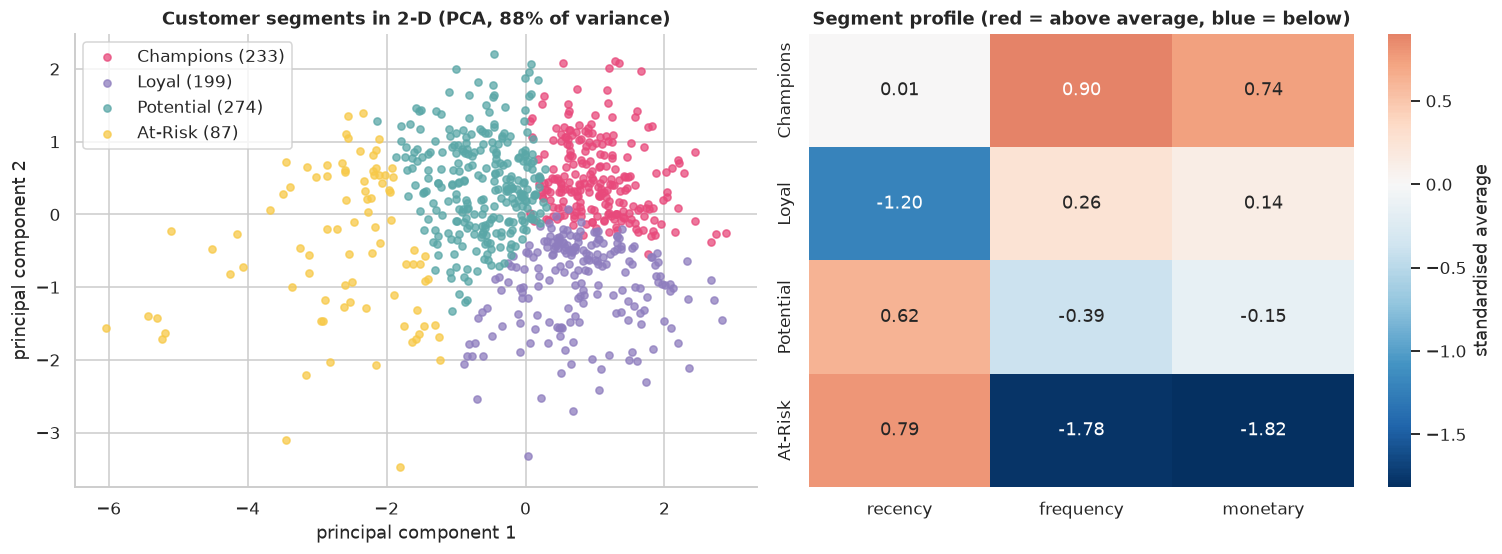

In [56]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pts = pca.fit_transform(X_rfm)
seg_order = list(profile.index)
seg_color = dict(zip(seg_order, [PALETTE[0], PALETTE[1], PALETTE[3], PALETTE[2], PALETTE[5], "#9A9AAE"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for s in seg_order:
    m = (rfm["segment"] == s).values
    axes[0].scatter(pts[m, 0], pts[m, 1], s=22, alpha=0.75, color=seg_color[s], label=f"{s} ({m.sum()})")
axes[0].set(title=f"Customer segments in 2-D (PCA, {pca.explained_variance_ratio_.sum():.0%} of variance)",
            xlabel="principal component 1", ylabel="principal component 2"); axes[0].legend()

centroids = pd.DataFrame(X_rfm, columns=["recency", "frequency", "monetary"]).groupby(rfm["segment"].values).mean().loc[seg_order]
sns.heatmap(centroids, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1], cbar_kws={"label": "standardised average"})
axes[1].set(title="Segment profile (red = above average, blue = below)", ylabel="")
plt.tight_layout(); plt.show()

In [57]:
for seg, row in profile.iterrows():
    print(f"• {seg:<10} {int(row['customers']):>4} customers · last order ~{row['avg_recency_days']:.0f} days ago · "
          f"{row['avg_orders']:.1f} orders · ${row['avg_spend']:,.0f} each · {row['revenue_share']:.0%} of revenue")

• Champions   233 customers · last order ~98 days ago · 8.7 orders · $4,909 each · 51% of revenue
• Loyal       199 customers · last order ~20 days ago · 6.7 orders · $2,676 each · 24% of revenue
• Potential   274 customers · last order ~223 days ago · 4.9 orders · $1,993 each · 24% of revenue
• At-Risk      87 customers · last order ~350 days ago · 2.6 orders · $447 each · 2% of revenue


**Marketing actions per segment** — *Champions*: reward and protect (early access, loyalty perks) · *Loyal*: upsell and cross-sell · *Potential*: nudge towards a second/third order · *At-Risk / Lost*: win-back campaigns with a personal touch.

### 8.4 Hierarchical clustering (comparison)
**Agglomerative (Ward) clustering** starts with every customer alone and repeatedly merges the two closest groups, producing a tree (**dendrogram**). It needs no random start, and we can compare it with K-Means: if two very different algorithms find similar groups, the structure is real.

,silhouette,Davies–Bouldin
K-Means,0.26,1.20
Agglomerative (Ward),0.23,1.28


Agreement between the two algorithms (Adjusted Rand Index): 0.38  (1 = identical groupings, 0 = unrelated)
Reading: only moderate agreement (and a silhouette of 0.26) → customers form a CONTINUUM rather than sharply separated islands. The segments are still useful as practical buckets, but their borders are soft.


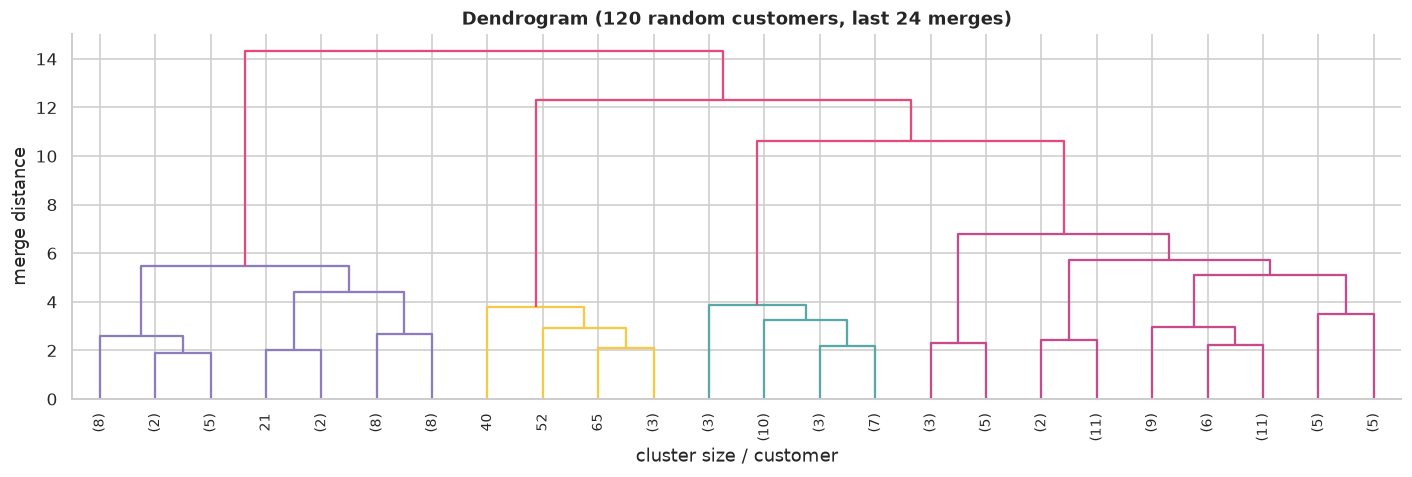

In [58]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward").fit(X_rfm)
comparison_cluster = pd.DataFrame({
    "silhouette": [silhouette_score(X_rfm, km.labels_), silhouette_score(X_rfm, agg.labels_)],
    "Davies–Bouldin": [davies_bouldin_score(X_rfm, km.labels_), davies_bouldin_score(X_rfm, agg.labels_)],
}, index=["K-Means", "Agglomerative (Ward)"]).round(3)
ari = adjusted_rand_score(km.labels_, agg.labels_)
display(comparison_cluster)
print(f"Agreement between the two algorithms (Adjusted Rand Index): {ari:.2f}  (1 = identical groupings, 0 = unrelated)")
sil_best = sil[ks.index(best_k)]
if ari >= 0.6:
    print("Reading: strong agreement → the customer groups are real, well-separated structure.")
else:
    print(f"Reading: only {'moderate' if ari >= 0.3 else 'weak'} agreement (and a silhouette of {sil_best:.2f}) → customers form a CONTINUUM rather than "
          "sharply separated islands. The segments are still useful as practical buckets, but their borders are soft.")

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(X_rfm), size=120, replace=False)
Z = linkage(X_rfm[sample_idx], method="ward")
fig, ax = plt.subplots(figsize=(13, 4.5))
dendrogram(Z, truncate_mode="lastp", p=24, leaf_rotation=90, leaf_font_size=9, color_threshold=0.7 * max(Z[:, 2]), ax=ax)
ax.set(title="Dendrogram (120 random customers, last 24 merges)", xlabel="cluster size / customer", ylabel="merge distance")
plt.tight_layout(); plt.show()

## 🛍️ 9. Association rules — the Apriori algorithm

**Association-rule mining** finds items that occur *together*. The classic example is market-basket analysis: *"customers who buy A also buy B."* Here a **basket = one order**, and the **items = the sub-categories** in it (a 47% share of orders contain more than one sub-category, so there is something to find).

### Key measures
For a rule **A ⇒ B** (N = number of orders):

| Measure | Formula | Meaning |
|---|---|---|
| **Support** | `count(A and B) / N` | How common is the combination? |
| **Confidence** | `count(A and B) / count(A)` | Of orders with A, how many also have B? |
| **Lift** | `confidence / support(B)` | How much more often B appears *given A* than by chance. **Lift > 1** = positive association, **= 1** = independent, **< 1** = they avoid each other |

### The Apriori principle
> *If an itemset is frequent, all of its subsets are frequent* — equivalently, **if a set is infrequent, no larger set containing it can be frequent.**

That lets the algorithm **prune** huge numbers of candidates: build frequent 1-item sets → combine them into candidate 2-item sets → keep the frequent ones → build 3-item candidates, and so on.

4,922 baskets · average 1.83 distinct sub-categories per order · 47% of orders have 2 or more


,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
0,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


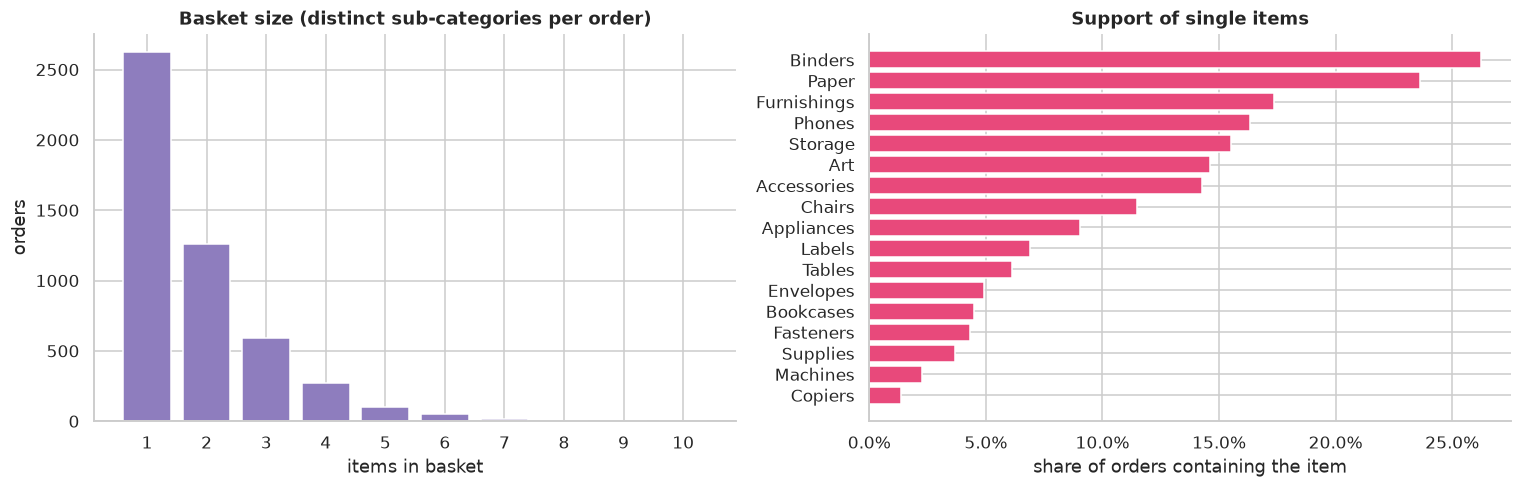

In [59]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

baskets = clean.groupby("Order ID")["Sub-Category"].apply(lambda s: sorted(set(s))).tolist()
N = len(baskets)
sizes = pd.Series([len(b) for b in baskets])
print(f"{N:,} baskets · average {sizes.mean():.2f} distinct sub-categories per order · {(sizes > 1).mean():.0%} of orders have 2 or more")

te = TransactionEncoder()
onehot = pd.DataFrame(te.fit(baskets).transform(baskets), columns=te.columns_)   # True/False matrix: order × item
display(onehot.head(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
vc = sizes.value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=PALETTE[1]); axes[0].set(title="Basket size (distinct sub-categories per order)", xlabel="items in basket", ylabel="orders")
supp = onehot.mean().sort_values()
axes[1].barh(supp.index, supp.values, color=PALETTE[0]); axes[1].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set(title="Support of single items", xlabel="share of orders containing the item")
plt.tight_layout(); plt.show()

### 9.1 Choosing minimum support
Too high → nothing interesting survives; too low → thousands of rules by chance. We look at how many frequent itemsets exist at different thresholds.

In [60]:
sens = []
for s in [0.10, 0.05, 0.03, 0.02, 0.01, 0.005]:
    fi = apriori(onehot, min_support=s, use_colnames=True)
    lens = fi["itemsets"].apply(len)
    sens.append({"min_support": s, "≈ orders": int(round(s * N)), "1-itemsets": int((lens == 1).sum()),
                 "2-itemsets": int((lens == 2).sum()), "3-itemsets": int((lens == 3).sum()), "total": len(fi)})
pd.DataFrame(sens).set_index("min_support")

,≈ orders,1-itemsets,2-itemsets,3-itemsets,total
min_support,,,,,
0.10,492,8,0,0,8
0.05,246,11,1,0,12
0.03,148,15,9,0,24
0.02,98,16,22,0,38
0.01,49,17,48,2,67
0.01,25,17,85,38,140


In [61]:
MIN_SUPPORT = 0.01          # an itemset must appear in at least ~1% of orders (≈ 49 orders)
freq = apriori(onehot, min_support=MIN_SUPPORT, use_colnames=True)
try:
    rules = association_rules(freq, num_itemsets=N, metric="confidence", min_threshold=0.10)
except TypeError:                                              # older mlxtend versions have no num_itemsets argument
    rules = association_rules(freq, metric="confidence", min_threshold=0.10)

rules = rules[rules["lift"] > 1].copy()                        # keep only positive associations
rules["rule"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s))) + "  ⇒  " + rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
rules["orders"] = (rules["support"] * N).round().astype(int)
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)
print(f"min_support = {MIN_SUPPORT:.0%} → {len(freq)} frequent itemsets → {len(rules)} rules with lift > 1")
rules[["rule", "orders", "support", "confidence", "lift"]].head(15).round(3)

min_support = 1% → 67 frequent itemsets → 21 rules with lift > 1


,rule,orders,support,confidence,lift
0,"Binders, Paper ⇒ Storage",52,0.01,0.20,1.25
1,"Binders, Paper ⇒ Phones",53,0.01,0.20,1.22
2,"Paper, Phones ⇒ Binders",53,0.01,0.31,1.20
3,"Binders, Phones ⇒ Paper",53,0.01,0.27,1.15
4,"Paper, Storage ⇒ Binders",52,0.01,0.30,1.14
5,Fasteners ⇒ Paper,57,0.01,0.27,1.14
6,"Binders, Storage ⇒ Paper",52,0.01,0.27,1.13
7,Labels ⇒ Storage,59,0.01,0.17,1.12
8,Fasteners ⇒ Binders,61,0.01,0.29,1.10
9,Appliances ⇒ Binders,126,0.03,0.28,1.08


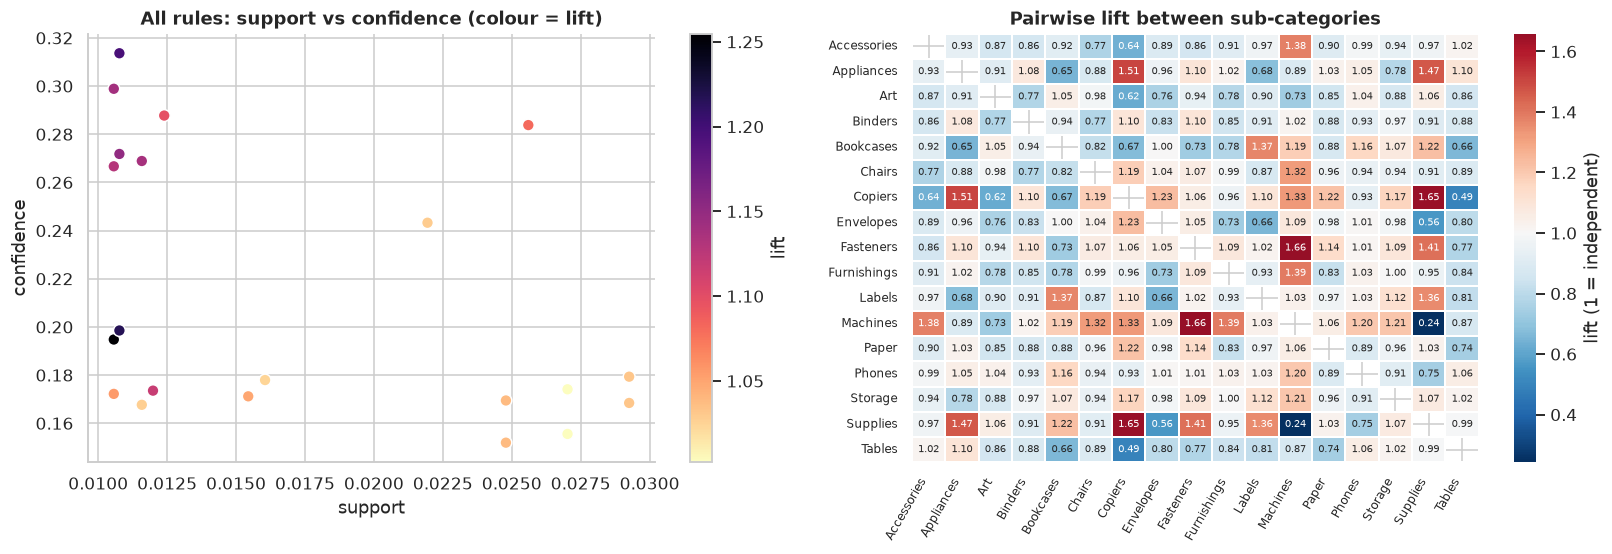

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sc = axes[0].scatter(rules["support"], rules["confidence"], c=rules["lift"], s=60, cmap="magma_r", edgecolor="white")
plt.colorbar(sc, ax=axes[0], label="lift")
axes[0].set(title="All rules: support vs confidence (colour = lift)", xlabel="support", ylabel="confidence")

A = onehot.values.astype(float)
co = (A.T @ A) / N                                           # P(A and B)
p = A.mean(axis=0)
lift_arr = co / np.outer(p, p)
np.fill_diagonal(lift_arr, np.nan)                             # an item with itself is not interesting
lift_mat = pd.DataFrame(lift_arr, index=onehot.columns, columns=onehot.columns)
sns.heatmap(lift_mat, cmap="RdBu_r", center=1, annot=True, fmt=".2f", annot_kws={"size": 6.5}, linewidths=0.3,
            cbar_kws={"label": "lift (1 = independent)"}, ax=axes[1])
axes[1].set(title="Pairwise lift between sub-categories", xlabel="", ylabel="")
plt.setp(axes[1].get_xticklabels(), rotation=60, ha="right", fontsize=8); plt.setp(axes[1].get_yticklabels(), fontsize=8)
plt.tight_layout(); plt.show()

### 9.2 A caution about rare pairs — and checking the formulas by hand
The heat-map shows some pairs with a *higher* lift than any rule in the table above. Why are they missing from the rules? Because they fall **below the minimum-support threshold**: they co-occur in very few orders, so the lift is easily a fluke. This is exactly why Apriori needs a support cut-off.
We take the top single-item rule and recompute its measures directly from the basket counts — if our understanding of support / confidence / lift is right, the numbers must match the library's.

In [63]:
pairs = [(lift_mat.index[i], lift_mat.columns[j], lift_mat.iloc[i, j], int(round(co[i, j] * N)))
         for i in range(len(lift_mat)) for j in range(i + 1, len(lift_mat))]
rare = pd.DataFrame(pairs, columns=["item A", "item B", "lift", "orders together"]).sort_values("lift", ascending=False).head(5)
print("Highest pairwise lifts overall — note how few orders support them:")
display(rare.reset_index(drop=True))
print("Compare with the rules table: those pairs have lift > 1.5 but appear in only a handful of orders → unreliable, which is why we require support ≥ 1%.\n")

single = rules[(rules["antecedents"].apply(len) == 1) & (rules["consequents"].apply(len) == 1)].iloc[0]
a, b = next(iter(single["antecedents"])), next(iter(single["consequents"]))
n_a, n_b, n_ab = int(onehot[a].sum()), int(onehot[b].sum()), int((onehot[a] & onehot[b]).sum())

support_hand    = n_ab / N
confidence_hand = n_ab / n_a
lift_hand       = confidence_hand / (n_b / N)
print(f"Rule: {a} ⇒ {b}")
print(f"  orders with {a}: {n_a} · orders with {b}: {n_b} · orders with both: {n_ab} · total orders: {N}")
print(f"  support    = {n_ab}/{N}      = {support_hand:.4f}   (library: {single['support']:.4f})")
print(f"  confidence = {n_ab}/{n_a}  = {confidence_hand:.4f}   (library: {single['confidence']:.4f})")
print(f"  lift       = {confidence_hand:.4f} / ({n_b}/{N}) = {lift_hand:.4f}   (library: {single['lift']:.4f})")
assert np.isclose(support_hand, single["support"]) and np.isclose(confidence_hand, single["confidence"]) and np.isclose(lift_hand, single["lift"])
print("✅ Hand calculation matches the library.")

Highest pairwise lifts overall — note how few orders support them:


,item A,item B,lift,orders together
0,Fasteners,Machines,1.66,8
1,Copiers,Supplies,1.65,4
2,Appliances,Copiers,1.51,9
3,Appliances,Supplies,1.47,24
4,Fasteners,Supplies,1.41,11


Compare with the rules table: those pairs have lift > 1.5 but appear in only a handful of orders → unreliable, which is why we require support ≥ 1%.

Rule: Fasteners ⇒ Paper
  orders with Fasteners: 212 · orders with Paper: 1163 · orders with both: 57 · total orders: 4922
  support    = 57/4922      = 0.0116   (library: 0.0116)
  confidence = 57/212  = 0.2689   (library: 0.2689)
  lift       = 0.2689 / (1163/4922) = 1.1379   (library: 1.1379)
✅ Hand calculation matches the library.


### 9.3 Apriori from scratch
To show we understand the algorithm and are not just calling a library, here is a compact implementation of the level-wise **generate → prune → count** loop. We then verify that it finds *exactly the same* frequent itemsets as `mlxtend`, and print how many candidates each level generated vs how many survived (the Apriori pruning in action).

In [64]:
def apriori_scratch(transactions, min_support):
    n = len(transactions)
    tx = [frozenset(t) for t in transactions]
    support = lambda itemset: sum(itemset <= t for t in tx) / n

    items = sorted({i for t in tx for i in t})
    level = {frozenset([i]): support(frozenset([i])) for i in items}
    stats = [(1, len(items), sum(v >= min_support for v in level.values()))]
    level = {k: v for k, v in level.items() if v >= min_support}
    frequent, k = dict(level), 2
    while level:
        prev = list(level)
        # JOIN: merge two frequent (k-1)-itemsets into a k-itemset
        # PRUNE: discard it unless ALL of its (k-1)-subsets are frequent (the Apriori principle)
        candidates = {a | b for a in prev for b in prev
                      if len(a | b) == k and all(frozenset(s) in level for s in combinations(a | b, k - 1))}
        level = {c: support(c) for c in candidates}
        stats.append((k, len(candidates), sum(v >= min_support for v in level.values())))
        level = {c: v for c, v in level.items() if v >= min_support}      # COUNT: keep only the frequent ones
        frequent.update(level)
        k += 1
    return frequent, stats

scratch, stats = apriori_scratch(baskets, MIN_SUPPORT)
library = {frozenset(i): s for i, s in zip(freq["itemsets"], freq["support"])}

same = set(scratch) == set(library)
max_diff = max(abs(scratch[k] - library[k]) for k in library) if same else float("nan")
print(f"From-scratch Apriori found {len(scratch)} frequent itemsets · mlxtend found {len(library)} · identical sets: {same} · max support difference: {max_diff:.1e}")
assert same, "implementations disagree"
pd.DataFrame(stats, columns=["level k", "candidates generated (after pruning)", "frequent itemsets kept"]).set_index("level k")

From-scratch Apriori found 67 frequent itemsets · mlxtend found 67 · identical sets: True · max support difference: 0.0e+00


,candidates generated (after pruning),frequent itemsets kept
level k,,
1,17,17
2,136,48
3,92,2
4,0,0


In [65]:
top_rule = rules.iloc[0]
print(f"Strongest rule (highest lift): {top_rule['rule']}  → lift {top_rule['lift']:.2f}, confidence {top_rule['confidence']:.0%}, in {top_rule['orders']} orders.")
print(f"Median lift across all {len(rules)} rules: {rules['lift'].median():.2f}.")
if rules["lift"].max() < 1.5:
    print("Reading: every lift is close to 1 → customers choose sub-categories almost independently. "
          "Bundles should be tested cautiously (A/B test) rather than assumed.")
else:
    print("Reading: some pairs are bought together clearly more often than chance → good candidates for bundles / cross-sell offers.")

Strongest rule (highest lift): Binders, Paper  ⇒  Storage  → lift 1.25, confidence 19%, in 52 orders.
Median lift across all 21 rules: 1.06.
Reading: every lift is close to 1 → customers choose sub-categories almost independently. Bundles should be tested cautiously (A/B test) rather than assumed.


## 🎁 10. Bonus

### 10.1 Anomaly detection (Isolation Forest)
Which months were *unusual*? **Isolation Forest** isolates points with random splits; points that are isolated quickly (few splits) are anomalies. No labels needed.

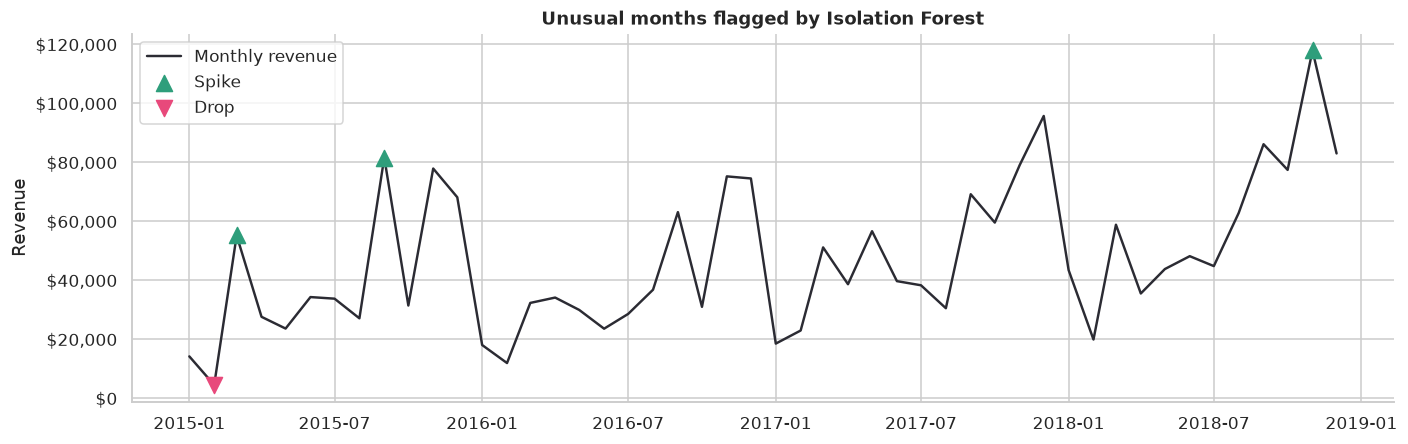

,month,revenue,change,type
0,Feb 2015,"4,519.89",-68%,drop
1,Mar 2015,"55,205.80",+1121%,spike
2,Sep 2015,"81,623.53",+201%,spike
3,Nov 2018,"117,938.15",+52%,spike


In [66]:
from sklearn.ensemble import IsolationForest

m = ts.to_frame("revenue")
m["pct_change"] = m["revenue"].pct_change().fillna(0)
Zs = StandardScaler().fit_transform(m[["revenue", "pct_change"]])
iso = IsolationForest(contamination=0.08, random_state=RANDOM_STATE).fit(Zs)
m["anomaly"] = iso.predict(Zs) == -1
flagged = m[m["anomaly"]].copy()
flagged["type"] = np.where(flagged["pct_change"] >= 0, "spike", "drop")

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(m.index, m["revenue"], color="#2B2B33", lw=1.6, label="Monthly revenue")
sp, dr = flagged[flagged["type"] == "spike"], flagged[flagged["type"] == "drop"]
ax.scatter(sp.index, sp["revenue"], s=110, marker="^", color="#2E9E7B", zorder=3, label="Spike")
ax.scatter(dr.index, dr["revenue"], s=110, marker="v", color=PALETTE[0], zorder=3, label="Drop")
ax.yaxis.set_major_formatter(money); ax.set(title="Unusual months flagged by Isolation Forest", ylabel="Revenue"); ax.legend()
plt.tight_layout(); plt.show()
flagged.assign(month=flagged.index.strftime("%b %Y"), change=flagged["pct_change"].map("{:+.0%}".format))[["month", "revenue", "change", "type"]].reset_index(drop=True)

### 10.2 A live interactive version (optional extra)
Everything above is also packaged as a small **interactive web application** (Streamlit): upload any sales CSV and get the dashboard, customer segments, forecast and AI-written recommendations.
It is only an *extra* — the notebook is the complete, self-contained submission.

🌐 **Live demo:** https://lumi-sales-analytics.onrender.com  *(free hosting: the first load after idle time can take up to a minute)*

## ✅ 11. Conclusions

In [67]:
summary = pd.DataFrame([
    ("Web scraping",       f"{len(state_pop)} state populations scraped ({scrape_source}); joined to all {clean['State'].nunique()} sales states"),
    ("Pre-processing",     f"{len(raw):,} → {len(clean):,} rows; {int(clean['postal_imputed'].sum())} missing ZIPs imputed, {n_dupes_raw} duplicate removed, dates & ZIP types fixed, "
                           f"{int(clean['is_outlier'].sum()):,} outliers flagged and log-transformed (skew {clean['Sales'].skew():.1f} → {clean['log_sales'].skew():.1f})"),
    ("Star schema / OLAP", f"1 fact table ({len(fact_sales):,} rows) + 5 dimensions; 0 FK violations; roll-up, drill-down, slice, dice, pivot queries"),
    ("Classification",     f"6 algorithms compared; top F1 {clf_results.loc[best_clf, 'F1']:.2f} ({best_clf}), ROC-AUC {clf_results.loc[best_clf, 'ROC-AUC']:.2f}; the best {len(tied)} are a statistical tie"),
    ("Regression",         f"R² {reg_results.loc[best_reg, 'R²']:.2f} on log(Sales) ({best_reg}); monthly revenue forecast: {best_ts} wins the backtest with MAPE {ts_results.loc[best_ts, 'MAPE %']:.1f}%"),
    ("Clustering",         f"K-Means k = {best_k} chosen by elbow + silhouette ({sil[ks.index(best_k)]:.2f}); agreement with hierarchical ARI {ari:.2f}"),
    ("Association rules",  f"Apriori at {MIN_SUPPORT:.0%} support → {len(rules)} rules; top lift {rules['lift'].max():.2f}; custom implementation verified against mlxtend"),
], columns=["Technique", "Result"])
pd.set_option("display.max_colwidth", 200)
summary

,Technique,Result
0,Web scraping,51 state populations scraped (live scrape of Wikipedia); joined to all 49 sales states
1,Pre-processing,"9,800 → 9,799 rows; 11 missing ZIPs imputed, 1 duplicate removed, dates & ZIP types fixed, 1,145 outliers flagged and log-transformed (skew 13.0 → 0.3)"
2,Star schema / OLAP,"1 fact table (9,799 rows) + 5 dimensions; 0 FK violations; roll-up, drill-down, slice, dice, pivot queries"
3,Classification,"6 algorithms compared; top F1 0.63 (Naive Bayes), ROC-AUC 0.85; the best 4 are a statistical tie"
4,Regression,R² 0.45 on log(Sales) (XGBoost); monthly revenue forecast: XGBoost wins the backtest with MAPE 19.6%
5,Clustering,K-Means k = 4 chosen by elbow + silhouette (0.26); agreement with hierarchical ARI 0.38
6,Association rules,Apriori at 1% support → 21 rules; top lift 1.25; custom implementation verified against mlxtend


### Business insights
1. **Plan for the year-end peak.** November–December carry a disproportionate share of revenue (see EDA 5.6) — inventory, staffing and marketing should be front-loaded for them.
2. **Protect the top customers, win back the rest.** Revenue is concentrated in a small share of customers; the *Champions* segment needs retention care, while *At-Risk / Lost* customers are an inexpensive win-back target.
3. **Product mix decides the sale size.** Both the EDA and the classifier agree that sub-category is the dominant driver of high-value sales — promote the high-ticket lines.
4. **Per-resident view reshuffles the geography.** The warehouse + scraped population surface smaller states that out-perform big ones per head (section 4.5 ⑥) — information total-revenue rankings hide.
5. **Bundle with care.** Basket analysis finds only weak co-purchase patterns; test bundles before rolling them out.

### Limitations
* **One measure only** (`Sales`): no quantity, discount, cost or profit, so we model revenue not margin, and regression R² is moderate.
* **One retailer, 2015–2018** — patterns may not transfer to other businesses or to today.
* **Population is from the 2020 Census** while sales are 2015–2018 — a reasonable proxy, not an exact match.
* Association rules are based on 17 broad sub-categories rather than individual products.

### Future work
Add quantity / discount / cost to the fact table; connect a BI tool (Power BI / Tableau) directly to the star schema; automate the scrape and ETL on a schedule; add customer-churn prediction and next-basket recommendation.

### References
* Dataset — Superstore Sales, Kaggle (rohitsahoo/sales-forecasting).
* Population data — Wikipedia, *List of U.S. states and territories by population* (CC BY-SA).
* R. Kimball & M. Ross, *The Data Warehouse Toolkit* (star schema, fact/dimension design).
* J. Han, M. Kamber & J. Pei, *Data Mining: Concepts and Techniques*.
* R. Agrawal & R. Srikant, *Fast Algorithms for Mining Association Rules* (Apriori, 1994).
* scikit-learn, XGBoost, statsmodels, mlxtend, pandas, seaborn documentation.